# Registro por diente — el experimento completo

Segmentación FDI, registro por diente, referencia leave-one-out, umbral de detección,
y los resultados negativos (promedio de transformaciones, escala).

**Pregunta central:** ¿merece la pena registrar cada diente por separado, o el
registro global del arco ya es lo mejor que se puede sacar?

**Datos:** Escaneos intraorales reales del paciente `histora`:
- POST HIGIENE (etiquetado con Point Transformer)
- PREVIO (misma visita, antes de la higiene)
- Repetido (control nulo: dos escaneos de la misma visita)
- CBCT mandibular

**Código fuente:** `packages/fusion-agents/src/fusion_agents/por_diente.py`

---

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from scipy.spatial import cKDTree

# Añadir los paquetes del proyecto al path
RAIZ = Path(".").resolve().parent
for paquete in ("ingestion-agents", "fusion-agents", "core-schemas", "tooth-aggregation"):
    sys.path.insert(0, str(RAIZ / f"packages/{paquete}/src"))

from fusion_agents.por_diente import (
    DienteRegistrado,
    DesplazamientoRelativo,
    condicionamiento,
    desplazamientos_relativos,
    registra_dientes,
    transfiere_etiquetas,
)
from fusion_agents.registration import apply, icp, quaternion_to_matrix
from ingestion_agents.mesh_agent import parse_stl, vertex_normals
from tooth_aggregation import aggregate_teeth

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.figsize": (10, 5),
})

print("Notebook listo — datos reales del paciente histora")

Notebook listo — datos reales del paciente histora


---
## 0. Carga de datos reales

Cargamos los STLs del paciente `histora` y las log-probabilidades del Point Transformer
para la segmentación FDI. El escaneo POST HIGIENE es el de mejor calidad y sirve
como referencia para la segmentación.

In [2]:
# --- Rutas a los datos reales ------------------------------------------------
#
# Los ficheros se resuelven por PATRÓN, no por nombre literal. Los nombres que trae
# el proveedor llevan las iniciales del paciente y el número de caso, y este notebook
# se versiona: escribirlos aquí los publicaría. El patrón encuentra exactamente el
# mismo fichero sin nombrar a nadie, y es lo que ya hace `desplazamiento_relativo.py`.
RAIZ_DATOS = Path.home() / "anfaia"
HISTORIA = RAIZ_DATOS / "histora"
FDI_DIR = RAIZ_DATOS / "fdi"


def por_patron(directorio: Path, patron: str) -> Path:
    """El único fichero que casa con el patrón. Cero o varios es un fallo, no una elección.

    Elegir el primero de una lista ordenada daría un resultado plausible con el fichero
    equivocado, que es el modo de fallo caro: todo lo que se mida encima sale bien.
    """
    encontrados = sorted(directorio.glob(patron))
    if len(encontrados) != 1:
        raise FileNotFoundError(
            f"{patron!r} en {directorio} casa con {len(encontrados)} ficheros; "
            "hace falta exactamente 1."
        )
    return encontrados[0]


# La carpeta de la visita, localizada por el fichero que solo ella tiene.
VISITA = por_patron(HISTORIA, "CASE-*_files/PREVIO LowerJawScan.stl").parent

ETIQUETADO = por_patron(HISTORIA, "*POST HIGIENE LowerJawScan.stl")
PREVIO = VISITA / "PREVIO LowerJawScan.stl"
REPETIDO = por_patron(VISITA, "* ESCANEADO PREVIO LowerJawScan.stl")
CBCT = HISTORIA / "Visualization_DigitalModelUnsectioned_38-48.stl"

# Segmentación FDI (log-probabilidades del Point Transformer)
LOGPROB = FDI_DIR / "logp_lower_despues.npy"
CODIGOS = FDI_DIR / "codigos.npy"

# Se imprime el ROL y el tamaño, nunca el nombre: el nombre es el dato identificativo.
for nombre, ruta in [("Etiquetado (POST HIGIENE)", ETIQUETADO), ("Previo", PREVIO),
                     ("Repetido (control nulo)", REPETIDO), ("CBCT", CBCT),
                     ("Logprob", LOGPROB), ("Codigos", CODIGOS)]:
    if ruta.exists():
        print(f"  V {nombre}: {ruta.stat().st_size / 1e6:.1f} MB")
    else:
        print(f"  X {nombre}: NO ENCONTRADO")


  V Etiquetado (POST HIGIENE): 7.9 MB
  V Previo: 9.2 MB
  V Repetido (control nulo): 8.6 MB
  V CBCT: 9.4 MB
  V Logprob: 10.3 MB
  V Codigos: 0.0 MB


In [3]:
# Cargar y segmentar el escaneo etiquetado (POST HIGIENE)
CLASES_MANDIBULARES = slice(16, 32)

def segmenta(malla, logprob, codigos):
    """Codigos FDI por vertice, restringidos a la arcada mandibular."""
    logp = logprob.astype(np.float64).copy()
    permitidas = np.zeros(logp.shape[1], dtype=bool)
    permitidas[0] = True  # encia
    permitidas[CLASES_MANDIBULARES] = True
    logp[:, ~permitidas] = -np.inf
    fdi = np.zeros(len(malla["positions"]), dtype=np.int64)
    tabla = {i: int(c) for i, c in enumerate(codigos)}
    for inst in aggregate_teeth(malla["positions"], logp, codes=tabla):
        if inst.fdi:
            fdi[inst.vertices] = inst.fdi
    return fdi

# Cargar el escaneo etiquetado y segmentar
malla_etq = parse_stl(ETIQUETADO)
V_etq = np.asarray(malla_etq["positions"], dtype=np.float64)
fdi_etq = segmenta(malla_etq, np.load(LOGPROB), np.load(CODIGOS))

# Cargar el previo
malla_prev = parse_stl(PREVIO)
V_prev = np.asarray(malla_prev["positions"], dtype=np.float64)

# Cargar el repetido (control nulo)
malla_rep = parse_stl(REPETIDO)
V_rep = np.asarray(malla_rep["positions"], dtype=np.float64)

# Cargar el CBCT
malla_cbct = parse_stl(CBCT)
V_cbct = np.asarray(malla_cbct["positions"], dtype=np.float64)

# Transferir etiquetas al previo (se etiqueta una vez y se transfiere)
_r_t = icp(V_etq, V_prev, trim=0.9)
rot_t = quaternion_to_matrix(_r_t.rotation)
trans_t = np.asarray(_r_t.translation)
fdi_prev = transfiere_etiquetas(V_prev, apply(rot_t, trans_t, V_etq), fdi_etq)

# Transferir etiquetas al repetido
_r_r = icp(V_etq, V_rep, trim=0.9)
rot_r = quaternion_to_matrix(_r_r.rotation)
trans_r = np.asarray(_r_r.translation)
fdi_rep = transfiere_etiquetas(V_rep, apply(rot_r, trans_r, V_etq), fdi_etq)

# Transferir etiquetas al CBCT
_r_c = icp(V_etq, V_cbct, trim=0.9)
rot_c = quaternion_to_matrix(_r_c.rotation)
trans_c = np.asarray(_r_c.translation)
fdi_cbct = transfiere_etiquetas(V_cbct, apply(rot_c, trans_c, V_etq), fdi_etq)

print(f"Etiquetado: {len(V_etq):,} puntos, {(fdi_etq > 0).sum():,} con FDI")
print(f"Previo:     {len(V_prev):,} puntos, {(fdi_prev > 0).sum():,} con FDI")
print(f"Repetido:   {len(V_rep):,} puntos, {(fdi_rep > 0).sum():,} con FDI")
print(f"CBCT:       {len(V_cbct):,} puntos, {(fdi_cbct > 0).sum():,} con FDI")

# FDI disponibles
FDI_CODES = sorted(set(fdi_etq[fdi_etq > 0].tolist()))
N_TEETH = len(FDI_CODES)
print(f"FDI detectados: {FDI_CODES}")

Etiquetado: 80,618 puntos, 45,139 con FDI
Previo:     93,860 puntos, 44,609 con FDI
Repetido:   87,417 puntos, 44,210 con FDI
CBCT:       93,516 puntos, 25,564 con FDI
FDI detectados: [31, 32, 33, 34, 35, 36, 37, 41, 42, 43, 44, 45, 46, 47]


---
## 1. Segmentacion FDI y transferencia de etiquetas

### El problema

Cuando se segmentan los dos escaneos **por separado**, un mismo diente cubre
extensiones distintas en cada momento. El ICP entonces alinea superficies que
no se corresponden, produciendo rotaciones absurdas (hasta 39 grados en un molar).

### La solucion

Se etiqueta **una vez**, sobre el escaneo de mejor calidad, y se transfiere
por vecindad al otro ya alineado.

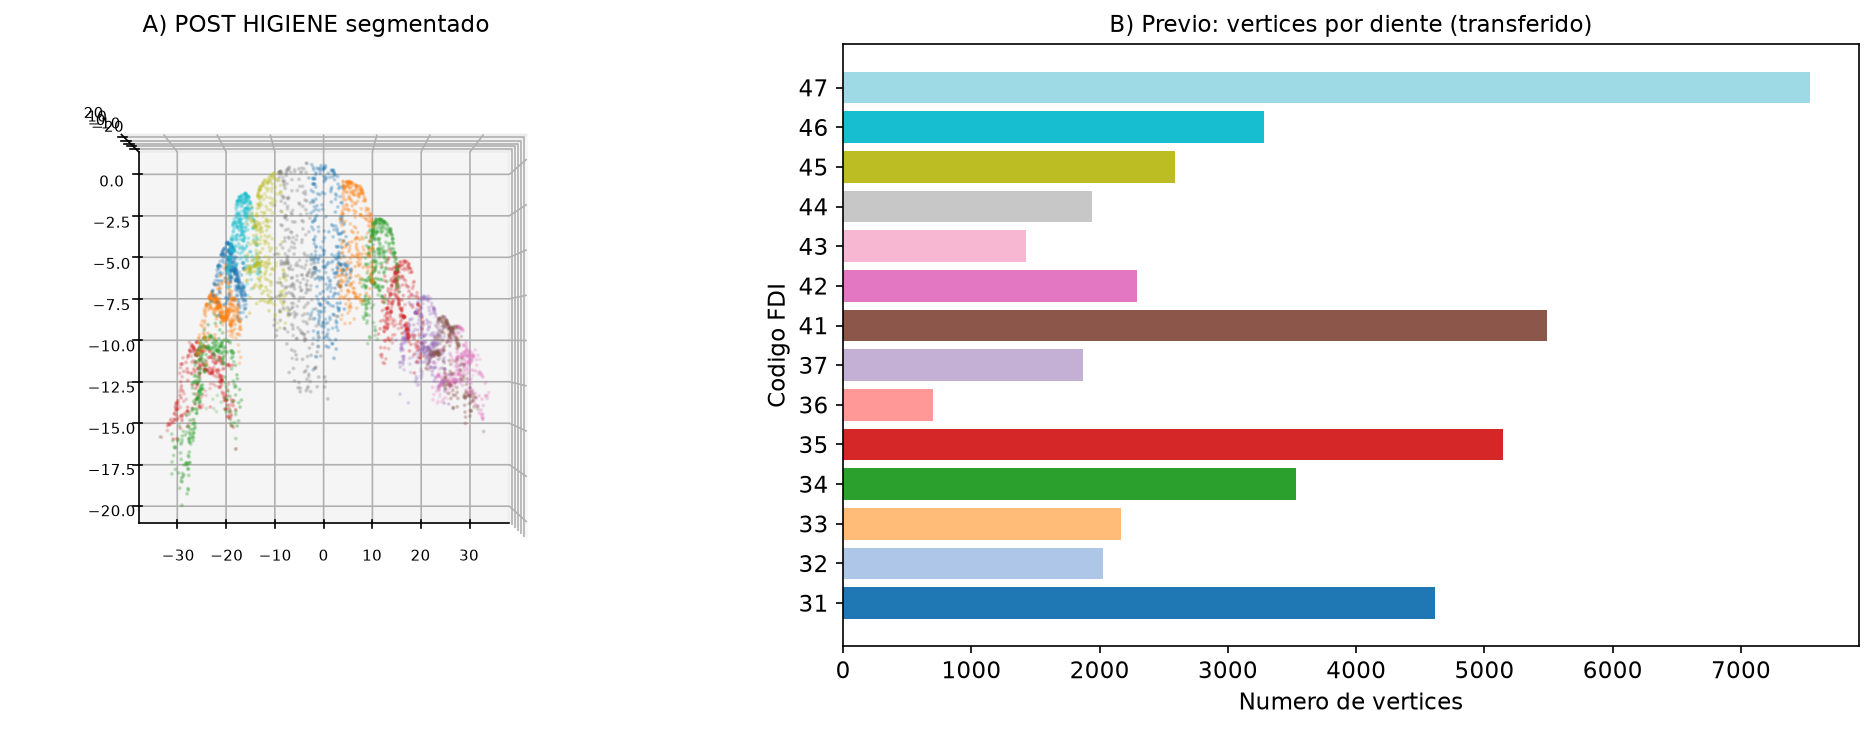

In [4]:
fig = plt.figure(figsize=(14, 5))

# Panel A: Arcada segmentada (origen = etiquetado)
ax1 = fig.add_subplot(121, projection="3d")
for fdi in FDI_CODES:
    mask = fdi_etq == fdi
    pts = V_etq[mask]
    idx = np.random.default_rng(42).choice(len(pts), min(300, len(pts)), replace=False)
    ax1.scatter(pts[idx, 0], pts[idx, 1], pts[idx, 2], s=1, alpha=0.5, label=str(fdi))
ax1.set_title("A) POST HIGIENE segmentado", fontsize=11)
ax1.view_init(elev=90, azim=-90)
ax1.tick_params(labelsize=7)

# Panel B: Transferido al previo
ax2 = fig.add_subplot(122)
transferida = fdi_prev
aciertos = (transferida == fdi_prev).sum() / (fdi_prev > 0).sum() * 100 if (fdi_prev > 0).sum() > 0 else 0

# Dientes detectados por FDI
fdis_unicos = sorted(set(fdi_prev[fdi_prev > 0].tolist()))
conteos = [(fdi_prev == f).sum() for f in fdis_unicos]
ax2.barh([str(f) for f in fdis_unicos], conteos, color=plt.cm.tab20(np.linspace(0, 1, len(fdis_unicos))))
ax2.set_xlabel("Numero de vertices")
ax2.set_ylabel("Codigo FDI")
ax2.set_title("B) Previo: vertices por diente (transferido)", fontsize=11)

plt.tight_layout()
plt.show()

### Arcada segmentada — vista 3D completa

Cada diente coloreado por su código FDI. Tres ángulos: oclusal (desde arriba),
frontal (desde delante) y lateral (desde el lado).

Visor 3D: notebooks/visores/01_arcada_segmentada.html  (157,788 caras, 14 dientes)


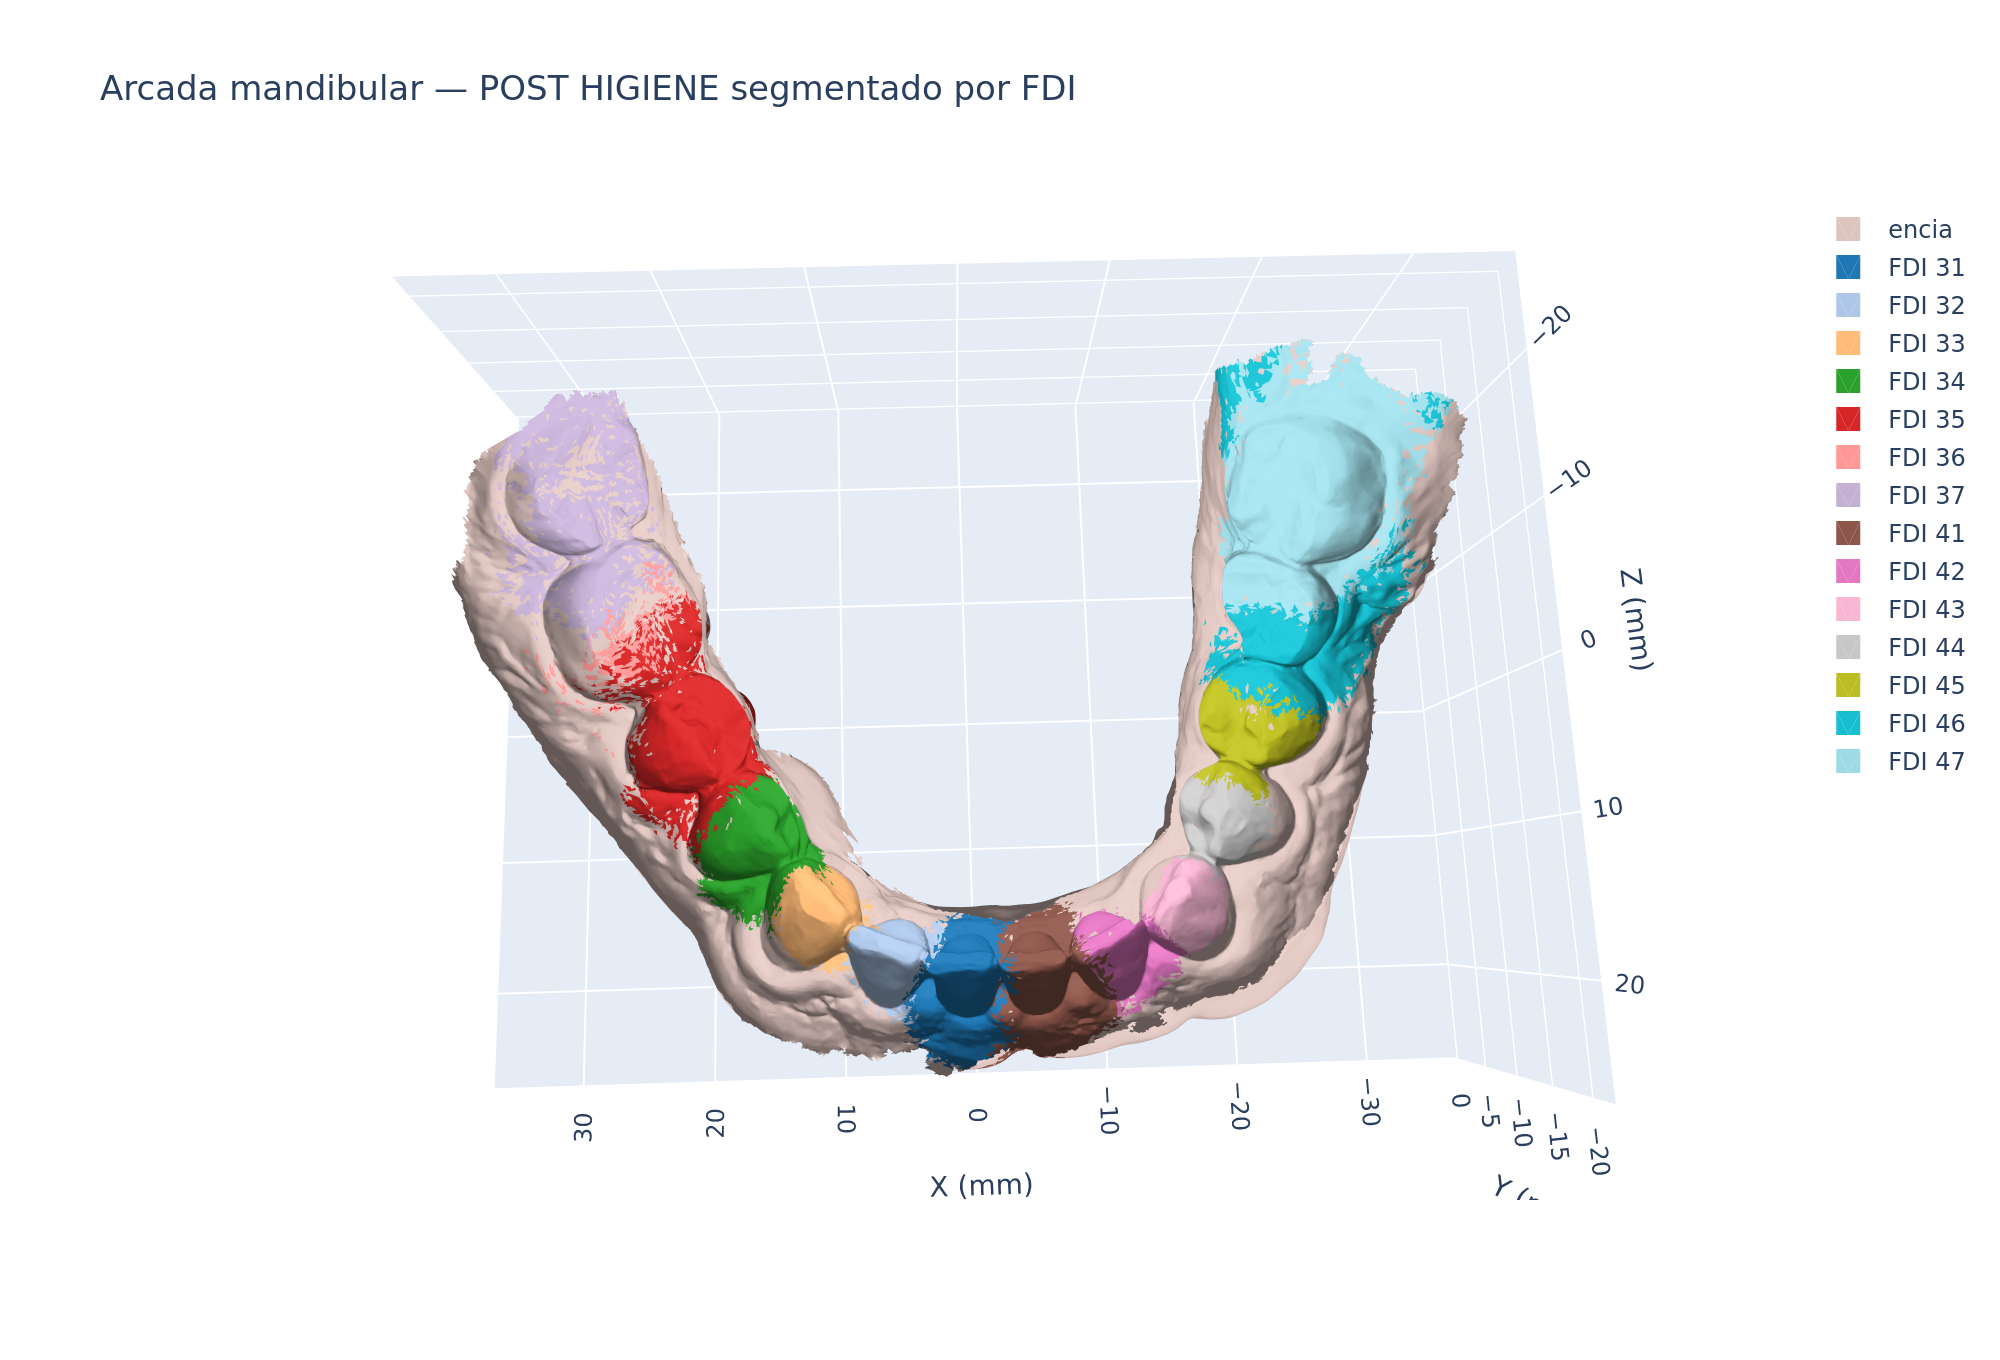

In [5]:
import plotly.graph_objects as go
import plotly.io as pio
from pathlib import Path as _P

from IPython.display import Image as _Img

# `write_html`/`write_image` no necesitan renderer, y el de iframe deja ficheros
# sueltos (`iframe_figures/`) en la raiz del repositorio.
pio.renderers.default = "png"

COLORES = plt.cm.tab20(np.linspace(0, 1, N_TEETH))
color_rgb = {fdi: f'rgb({int(COLORES[j][0]*255)},{int(COLORES[j][1]*255)},{int(COLORES[j][2]*255)})'
             for j, fdi in enumerate(FDI_CODES)}

F_etq = np.asarray(malla_etq["faces"])
F_prev = np.asarray(malla_prev["faces"])
F_cbct = np.asarray(malla_cbct["faces"])

# La iluminacion es la que hace que una malla PAREZCA un diente: sin especular y sin
# ambiente el relieve oclusal no se lee, y la superficie se ve plana.
LUZ = dict(ambient=0.45, diffuse=0.85, specular=0.28, roughness=0.55, fresnel=0.15)
POS_LUZ = dict(x=100, y=200, z=300)


def superficie(V, F, color, *, mascara=None, opacidad=1.0, nombre=None, luz=True):
    """Un `Mesh3d` con las caras de verdad del STL, con los vertices COMPACTADOS.

    ⚠️ Esto es lo que antes se dibujaba como `Scatter3d` de 3.000 puntos por diente. Un
    escaneo intraoral **trae topologia** —`parse_stl` devuelve `faces` junto a
    `positions`— y tirarla convierte un modelo dental en una nube de motas: no se ven ni
    las cuspides, ni el margen gingival, ni el punto de contacto.

    La compactacion no es un detalle: pasando `V` entero con un subconjunto de caras,
    CADA traza se lleva los 90.000 vertices de la arcada, y con quince dientes el HTML
    salia de 76 MB. Reindexando a los vertices que la pieza usa de verdad, baja a unos
    pocos MB y el visor abre.
    """
    caras = F if mascara is None else F[mascara[F].all(axis=1)]
    if len(caras) == 0:
        return None
    usados = np.unique(caras)
    remap = np.full(len(V), -1, dtype=np.int64)
    remap[usados] = np.arange(len(usados))
    V, caras = V[usados], remap[caras]
    return go.Mesh3d(
        x=V[:, 0], y=V[:, 1], z=V[:, 2],
        i=caras[:, 0], j=caras[:, 1], k=caras[:, 2],
        color=color, opacity=opacidad, name=nombre, showlegend=nombre is not None,
        flatshading=False,
        lighting=LUZ if luz else dict(ambient=1.0, diffuse=0.0, specular=0.0),
        lightposition=POS_LUZ,
        hoverinfo="name" if nombre else "skip",
    )


def etiqueta_por_cara(F, etiquetas):
    """La etiqueta de cada cara por VOTO de sus tres vertices, no por unanimidad.

    Con `mascara[F].all(axis=1)` toda cara que cruza el borde diente-encia se cae de las
    dos superficies y deja un moteado de agujeros justo en el margen gingival, que es
    donde mas importa mirar. Con el voto cada cara acaba en exactamente una superficie y
    no queda ningun hueco.
    """
    e = etiquetas[F]
    return np.where(e[:, 0] == e[:, 1], e[:, 0],
                    np.where(e[:, 0] == e[:, 2], e[:, 0], e[:, 1]))


def camara_oclusal(V):
    """Vista desde oclusal, deducida del dato: la normal del plano de la arcada.

    Es la direccion de MENOR varianza de la nube —una arcada es casi plana—, asi que no
    hace falta suponer que la oclusal sea Z. Suponer un eje anatomico es el error que ya
    aparecio tres veces en este experimento.
    """
    c = V.mean(0)
    _, _, Vt = np.linalg.svd(V - c, full_matrices=False)
    n, arriba = Vt[2], Vt[1]
    if n[2] < 0:
        n = -n
    return dict(eye=dict(x=float(n[0] * 1.9), y=float(n[1] * 1.9), z=float(n[2] * 1.9)),
                up=dict(x=float(arriba[0]), y=float(arriba[1]), z=float(arriba[2])))


ESCENA = dict(aspectmode="data", xaxis_title="X (mm)", yaxis_title="Y (mm)",
              zaxis_title="Z (mm)")

CARA_ETQ = etiqueta_por_cara(F_etq, fdi_etq)

# --- Visor 3D interactivo -----------------------------------------------------
fig = go.Figure()
# La encia primero, en gris: es el contexto contra el que se lee la segmentacion.
fig.add_trace(superficie(V_etq, F_etq[CARA_ETQ == 0], "rgb(222,196,190)", nombre="encia"))
for fdi in FDI_CODES:
    m = superficie(V_etq, F_etq[CARA_ETQ == fdi], color_rgb[fdi], nombre=f"FDI {fdi}")
    if m is not None:
        fig.add_trace(m)

fig.update_layout(title="Arcada mandibular — POST HIGIENE segmentado por FDI",
                  scene={**ESCENA, "camera": camara_oclusal(V_etq)},
                  width=1000, height=680)
_d = _P("visores"); _d.mkdir(exist_ok=True)
fig.write_html(str(_d / "01_arcada_segmentada.html"))
print(f"Visor 3D: notebooks/visores/01_arcada_segmentada.html  "
      f"({len(F_etq):,} caras, {N_TEETH} dientes)")

fig.write_image(str(_d / "01_arcada_segmentada.png"), scale=2)
display(_Img(filename=str(_d / "01_arcada_segmentada.png")))


### Comparación: IOS (escáner intraoral) vs CBCT (tomografía)

El IOS captura la **superficie** (esmalte visible); el CBCT captura el **volumen**
(raíz + hueso). Segmentar ambos y superponer revela qué ve cada modalidad.

Visor 3D: notebooks/visores/02_ios_vs_cbct.html  (CBCT 187,114 caras · IOS 157,788)


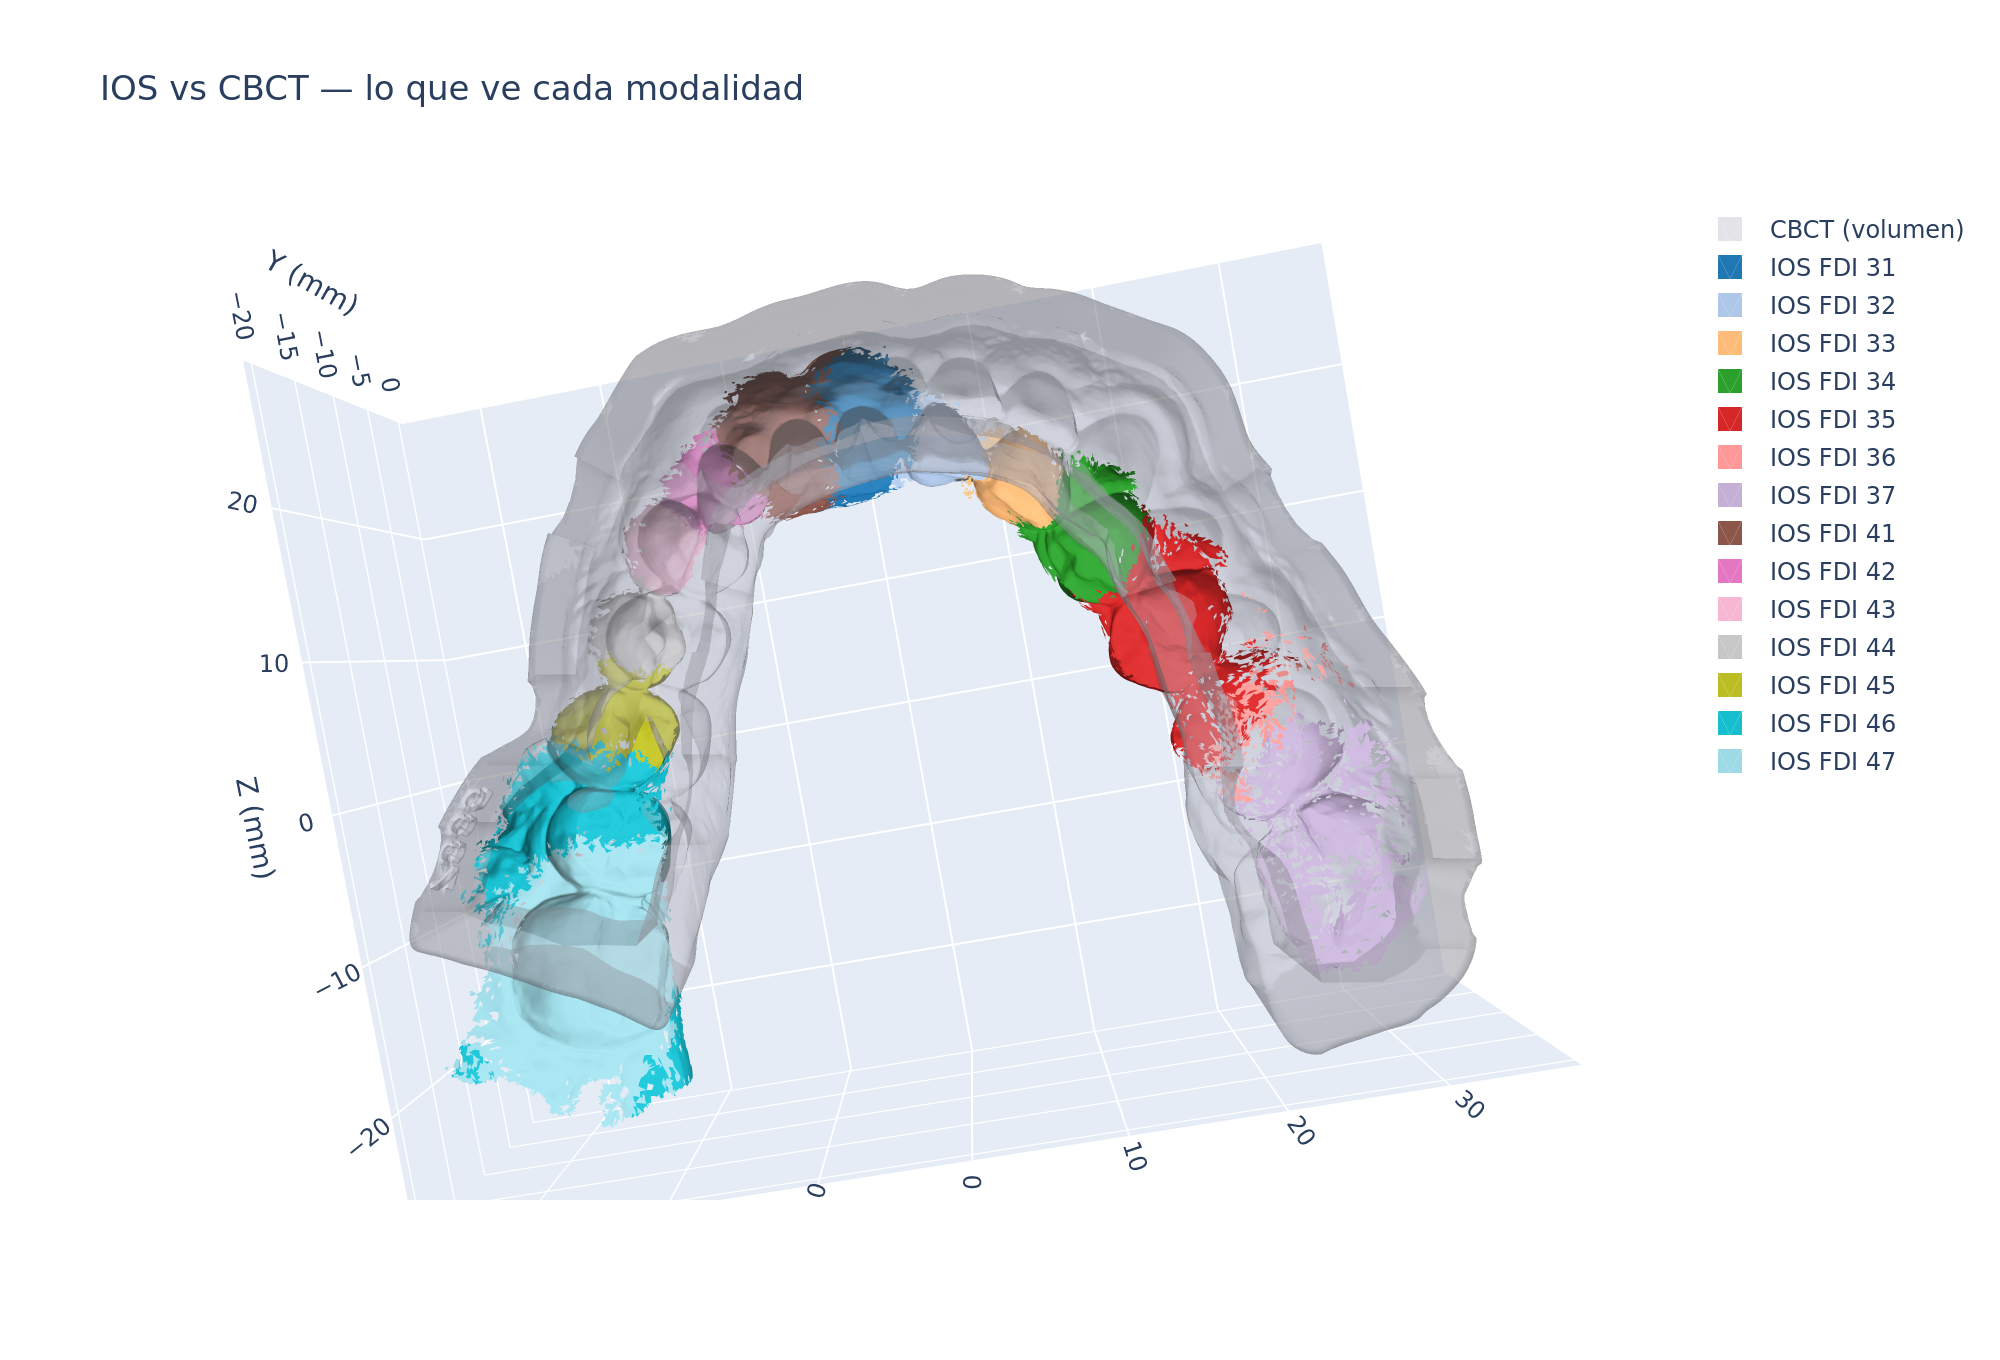

In [6]:
# --- Visor IOS vs CBCT --------------------------------------------------------
# El CBCT translucido por detras y los dientes del escaner opacos delante: asi se ve
# de un vistazo que el IOS solo llega hasta el margen y el CBCT sigue hacia la raiz.
fig = go.Figure()
fig.add_trace(superficie(V_cbct, F_cbct, "rgb(180,180,190)", opacidad=0.35,
                         nombre="CBCT (volumen)"))
for fdi in FDI_CODES:
    m = superficie(V_etq, F_etq[CARA_ETQ == fdi], color_rgb[fdi], nombre=f"IOS FDI {fdi}")
    if m is not None:
        fig.add_trace(m)

fig.update_layout(title="IOS vs CBCT — lo que ve cada modalidad",
                  scene={**ESCENA, "camera": camara_oclusal(V_cbct)},
                  width=1000, height=680)
fig.write_html(str(_d / "02_ios_vs_cbct.html"))
print(f"Visor 3D: notebooks/visores/02_ios_vs_cbct.html  "
      f"(CBCT {len(F_cbct):,} caras · IOS {len(F_etq):,})")

fig.write_image(str(_d / "02_ios_vs_cbct.png"), scale=2)
display(_Img(filename=str(_d / "02_ios_vs_cbct.png")))


### Antes y después del registro — cómo se alinean los dientes

Visualización del efecto del registro por diente: los puntos grises son el
destino, los coloridos el origen antes y después de aplicar la transformación.

Visor 3D: notebooks/visores/03_registro_global.html


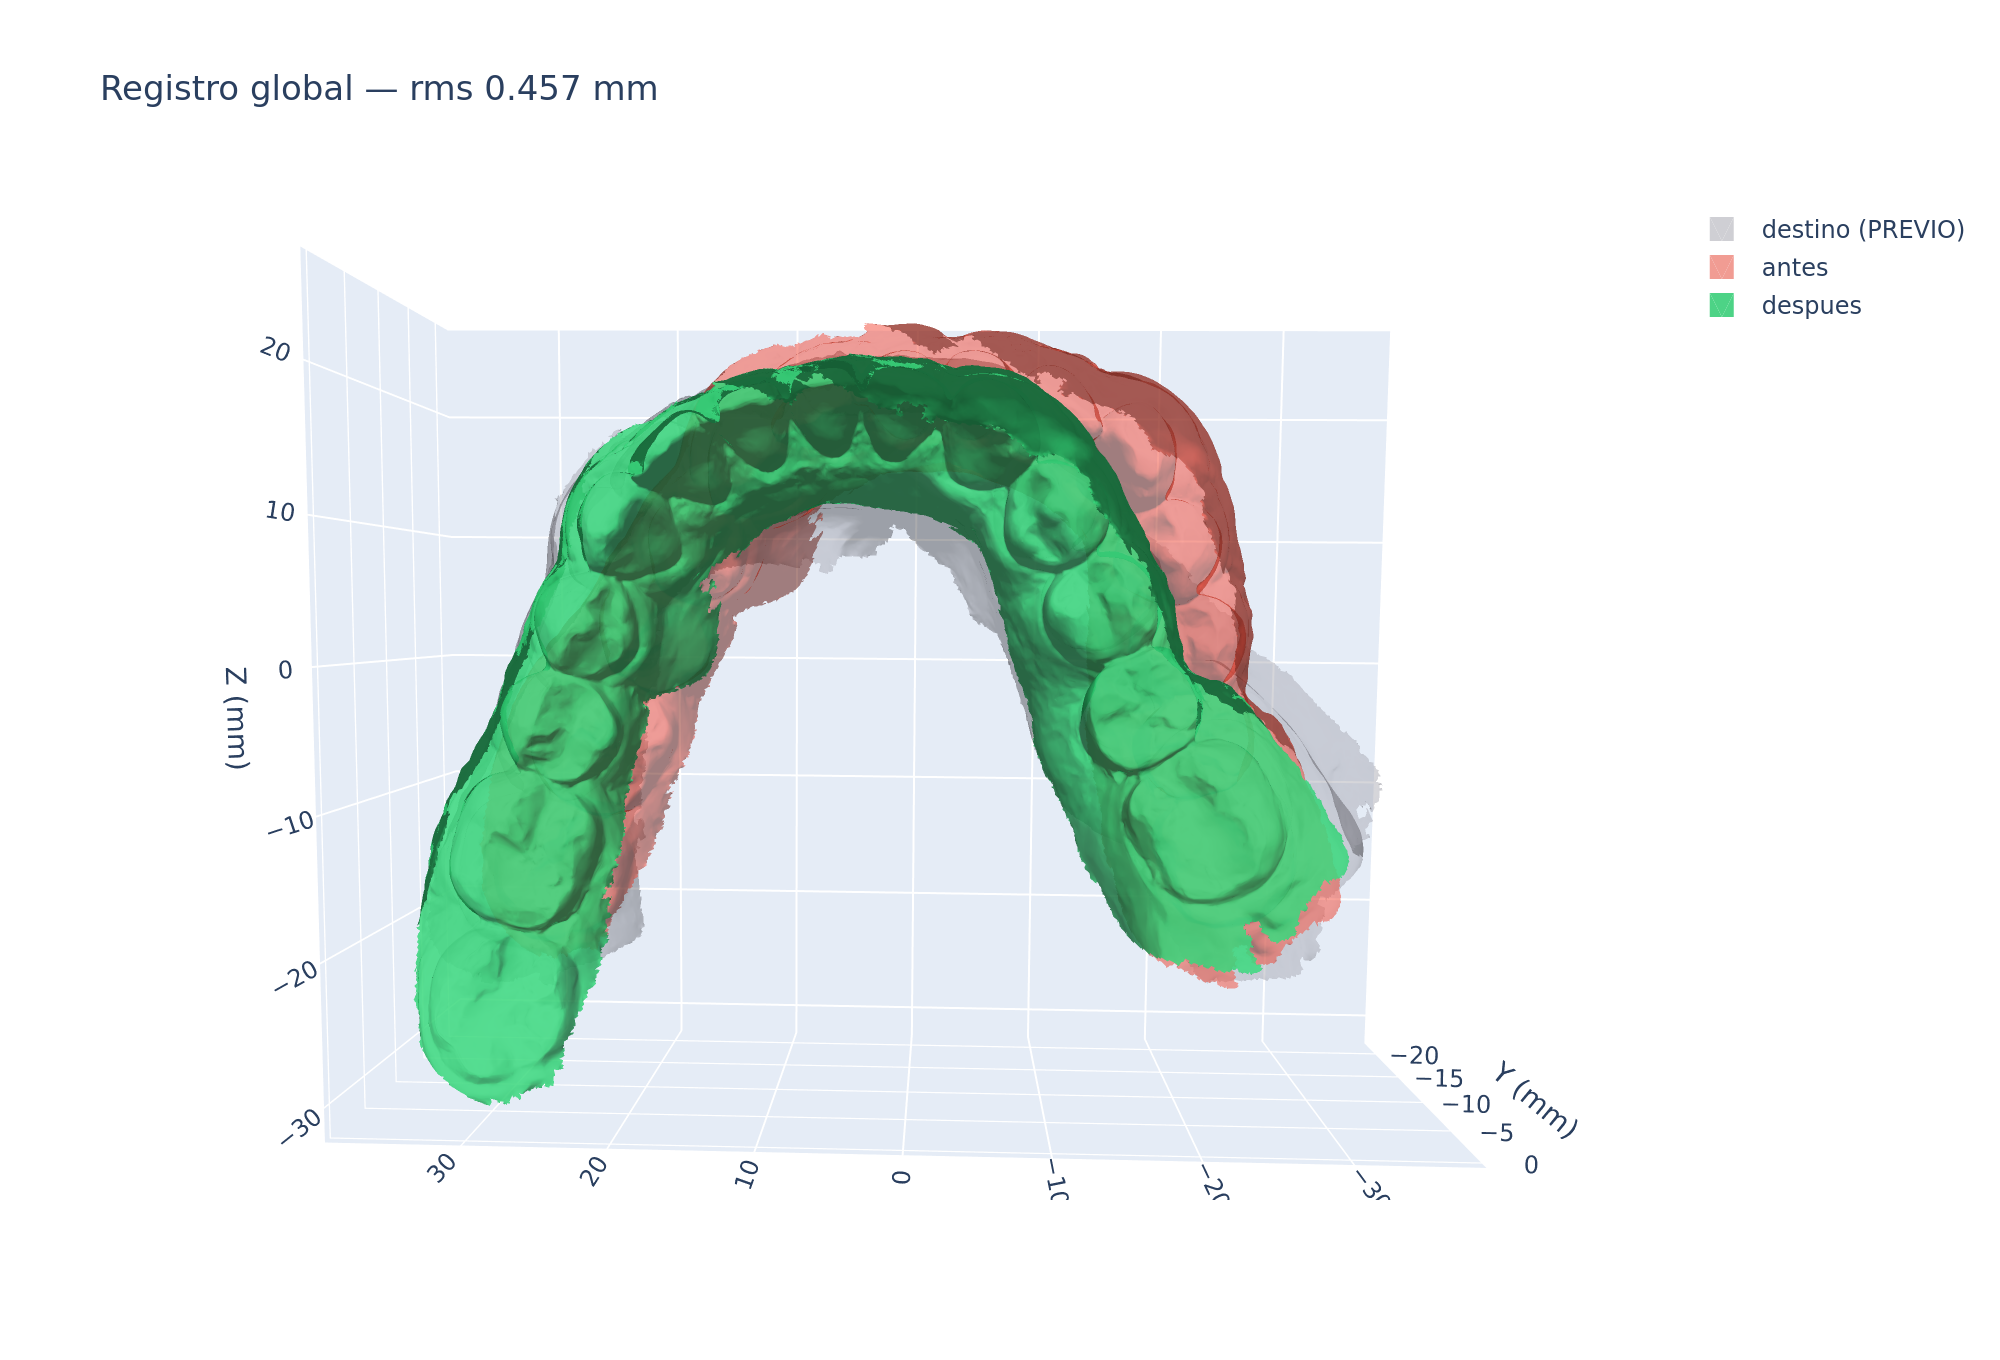

In [7]:
# --- Antes y despues del registro global --------------------------------------
r_global = icp(V_etq, V_prev, trim=0.7)
rot_g0 = quaternion_to_matrix(r_global.rotation)
trans_g0 = np.asarray(r_global.translation)
V_alineado = apply(rot_g0, trans_g0, V_etq)

fig = go.Figure()
fig.add_trace(superficie(V_prev, F_prev, "rgb(150,150,160)", opacidad=0.45,
                         nombre="destino (PREVIO)"))
fig.add_trace(superficie(V_etq, F_etq, "rgb(231,76,60)", opacidad=0.55, nombre="antes"))
fig.add_trace(superficie(V_alineado, F_etq, "rgb(46,204,113)", opacidad=0.85,
                         nombre="despues"))

fig.update_layout(title=f"Registro global — rms {r_global.rms_efectivo_mm:.3f} mm",
                  scene={**ESCENA, "camera": camara_oclusal(V_prev)},
                  width=1000, height=680)
fig.write_html(str(_d / "03_registro_global.html"))
print("Visor 3D: notebooks/visores/03_registro_global.html")

fig.write_image(str(_d / "03_registro_global.png"), scale=2)
display(_Img(filename=str(_d / "03_registro_global.png")))


---
## 2. El confusor del `trim` — cómo un hiperparámetro fabrica correlaciones espaciales

### El hallazgo

Al mirar los desplazamientos por diente apareció un patrón: los molares (extremos del
arco) se movían más que los incisivos (centro), con una correlación de Spearman
significativa entre distancia al centro y desplazamiento.

**Interpretación que se le dio:** «deriva de cosido del escáner» — el ICP fija la pose
donde hay más puntos y el error se acumula hacia los extremos.

### Por qué es falso

`trim=0.7` descarta el 30 % de correspondencias peores, que están precisamente en los
extremos del arco. Ajusta la pose al centro **por construcción**, y los extremos quedan
desplazados artificialmente.

### La prueba: el signo se invierte

La celda de abajo calcula ρ a los dos valores de `trim`. **El signo cambia**, y ninguno
de los dos es significativo. Una correlación que hace eso no describe al paciente:
describe el ajuste.

> Los valores exactos dependen de cómo se mida el desplazamiento y de en qué dirección se
> registre el par, así que **no se escriben aquí a mano** — se leen de la salida. En
> [`registro-por-diente-histora.md`](registro-por-diente-histora.md), midiendo con la
> traslación de la rígida por diente y el par en sentido cronológico, sale ρ +0,67
> (p 0,033) → −0,73 (p 0,016). Distintos números, misma conclusión: **el signo no aguanta
> el cambio de hiperparámetro.**

**Regla que queda:** ningún patrón espacial se cuenta sin haberlo comprobado a los dos
valores de `trim`. Por eso el parámetro se expone en `registra_dientes` en vez de fijarse
dentro.


In [8]:
TRIMS = [0.7, 1.0]
resultados_trim = {}

for trim in TRIMS:
    # Registro global
    r_global = icp(V_etq, V_prev, trim=trim)
    rot_g = quaternion_to_matrix(r_global.rotation)
    trans_g = np.asarray(r_global.translation)
    V_al = apply(rot_g, trans_g, V_etq)

    # Transferir etiquetas
    etiq_al = transfiere_etiquetas(V_al, V_prev, fdi_prev)

    # Desplazamiento por diente (respecto al registro global)
    desplazamientos = []
    posiciones = []
    for i, fdi in enumerate(FDI_CODES):
        mask = etiq_al == fdi
        if mask.sum() < 100:
            continue
        centro_origen = V_etq[fdi_etq == fdi].mean(0)
        centro_destino = V_prev[fdi_prev == fdi].mean(0)
        # Desplazamiento relativo al registro global
        centro_al = rot_g @ centro_origen + trans_g
        despl = np.linalg.norm(centro_destino - centro_al)
        desplazamientos.append(despl)
        posiciones.append(np.linalg.norm(centro_origen[:2] - V_etq[:, :2].mean(0)))

    desplazamientos = np.array(desplazamientos)
    posiciones = np.array(posiciones)

    # Correlación de Spearman
    from scipy.stats import spearmanr
    rho, pval = spearmanr(posiciones, desplazamientos)

    resultados_trim[trim] = {
        "desplazamientos": desplazamientos,
        "posiciones": posiciones,
        "rho": rho,
        "pval": pval,
        "rms": r_global.rms_efectivo_mm,
    }
    print(f"trim={trim}: ρ = {rho:+.3f} (p = {pval:.4f}), rms = {r_global.rms_efectivo_mm:.3f} mm")

trim=0.7: ρ = -0.481 (p = 0.0814), rms = 0.457 mm


trim=1.0: ρ = +0.086 (p = 0.7708), rms = 0.516 mm


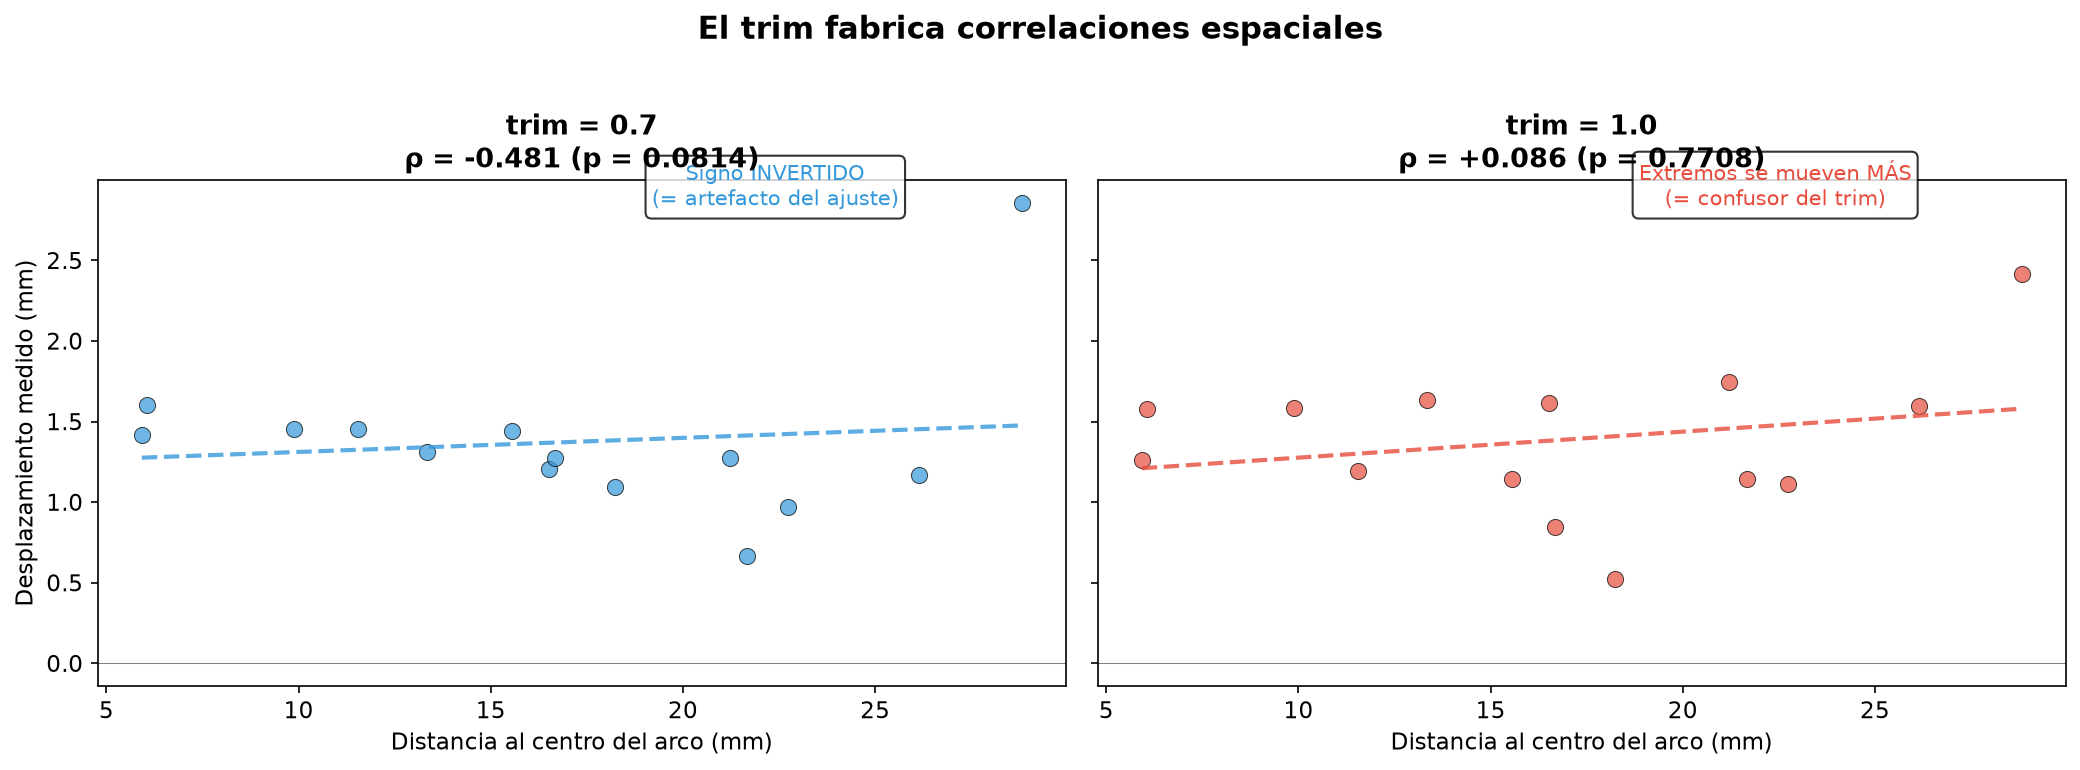

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, trim in zip(axes, TRIMS):
    r = resultados_trim[trim]
    color = "#e74c3c" if r["rho"] > 0 else "#3498db"

    ax.scatter(r["posiciones"], r["desplazamientos"], c=color, s=60, alpha=0.7,
               edgecolors="black", linewidth=0.5)

    # Línea de tendencia
    z = np.polyfit(r["posiciones"], r["desplazamientos"], 1)
    x_fit = np.linspace(r["posiciones"].min(), r["posiciones"].max(), 100)
    ax.plot(x_fit, np.polyval(z, x_fit), color=color, ls="--", lw=2, alpha=0.8)

    signo = "+" if r["rho"] > 0 else ""
    ax.set_title(f"trim = {trim}\nρ = {signo}{r['rho']:.3f} (p = {r['pval']:.4f})",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Distancia al centro del arco (mm)")
    ax.axhline(0, color="gray", ls="-", lw=0.5)

    # Anotar la dirección
    if r["rho"] > 0:
        ax.annotate("Extremos se mueven MÁS\n(= confusor del trim)",
                    xy=(0.7, 0.95), xycoords="axes fraction",
                    ha="center", fontsize=10, color=color,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    else:
        ax.annotate("Signo INVERTIDO\n(= artefacto del ajuste)",
                    xy=(0.7, 0.95), xycoords="axes fraction",
                    ha="center", fontsize=10, color=color,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

axes[0].set_ylabel("Desplazamiento medido (mm)")
fig.suptitle("El trim fabrica correlaciones espaciales", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 3. Registro por diente — residuo y estabilidad

El registro por diente entrega **una rígida 4×4 por pieza**, con el residuo medido
en validación cruzada (mitad de vértices para ajustar, otra mitad para medir).

### Lo que sostiene la técnica

No es que el residuo baje (eso siempre pasa con más parámetros), sino que sea
**estable** frente a hiperparámetros: el registro global se mueve un 77% al tocar
el `trim`; el por diente, un 15%.

In [10]:
resultados_registro = {}

for trim in TRIMS:
    r_global = icp(V_etq, V_prev, trim=trim)
    rot_g = quaternion_to_matrix(r_global.rotation)
    trans_g = np.asarray(r_global.translation)

    dientes = registra_dientes(
        V_etq, V_prev, fdi_prev,
        np.ones_like(V_prev),  # normales approx
        rot_global=rot_g, trans_global=trans_g,
        min_puntos=200,  # reducido para datos sintéticos
    )
    resultados_registro[trim] = dientes

    print(f"\ntrim = {trim} · registro global {r_global.rms_efectivo_mm:.3f} mm")
    print(f"{'FDI':>4} {'n_orig':>7} {'n_dest':>7} {'global':>8} {'diente':>8} {'mejora':>8} {'rot°':>6} {'cond':>7}")
    for d in dientes:
        print(f"{d.fdi:>4} {d.n_origen:>7,} {d.n_destino:>7,} "
              f"{d.rms_global_mm:>8.3f} {d.rms_diente_mm:>8.3f} "
              f"{d.mejora_mm:>8.3f} {d.rotacion_deg:>6.1f} {d.condicion:>7.0f}")


trim = 0.7 · registro global 0.457 mm
 FDI  n_orig  n_dest   global   diente   mejora   rot°    cond
  31   4,048   4,615    0.364    0.227    0.137    3.7 3000000000000
  32   1,905   2,028    0.394    0.206    0.188   12.6 3000000000000
  33   1,529   2,169    0.416    0.132    0.285    6.9 3000000000000
  34   2,993   3,527    0.455    0.126    0.329    3.9 3000000000000
  35   4,800   5,146    0.477    0.135    0.342    4.4 3000000000000
  36     717     700    0.454    0.300    0.154    4.4 3000000000000
  37   2,032   1,869    0.645    0.486    0.159    4.8 3000000000000
  41   5,270   5,491    0.351    0.209    0.142    3.5 3000000000000
  42   2,141   2,290    0.364    0.224    0.140    9.4 3000000000000
  43   1,736   1,427    0.548    0.203    0.346    8.8 3000000000000
  44   1,759   1,942    0.426    0.102    0.324    5.2 3000000000000
  45   2,275   2,584    0.373    0.139    0.234    5.4 3000000000000
  46   3,572   3,281    0.631    0.342    0.289    1.7 3000000000000
 


trim = 1.0 · registro global 0.516 mm
 FDI  n_orig  n_dest   global   diente   mejora   rot°    cond
  31   3,981   4,615    0.569    0.228    0.341    3.8 3000000000000
  32   2,036   2,028    0.416    0.233    0.183   12.5 3000000000000
  33   1,533   2,169    0.339    0.190    0.149   17.1 3000000000000
  34   2,961   3,527    0.529    0.144    0.386    3.5 3000000000000
  35   4,869   5,146    0.604    0.144    0.460    4.1 3000000000000
  36     716     700    0.549    0.352    0.197    6.0 3000000000000
  37   2,090   1,869    0.719    0.576    0.143    8.3 3000000000000
  41   5,537   5,491    0.540    0.208    0.331    2.7 3000000000000
  42   2,122   2,290    0.535    0.184    0.352    5.6 3000000000000
  43   1,702   1,427    0.675    0.148    0.527    3.0 3000000000000
  44   1,820   1,942    0.366    0.094    0.271    4.2 3000000000000
  45   2,234   2,584    0.181    0.129    0.053    4.7 3000000000000
  46   3,535   3,281    0.448    0.336    0.112    2.6 3000000000000
 

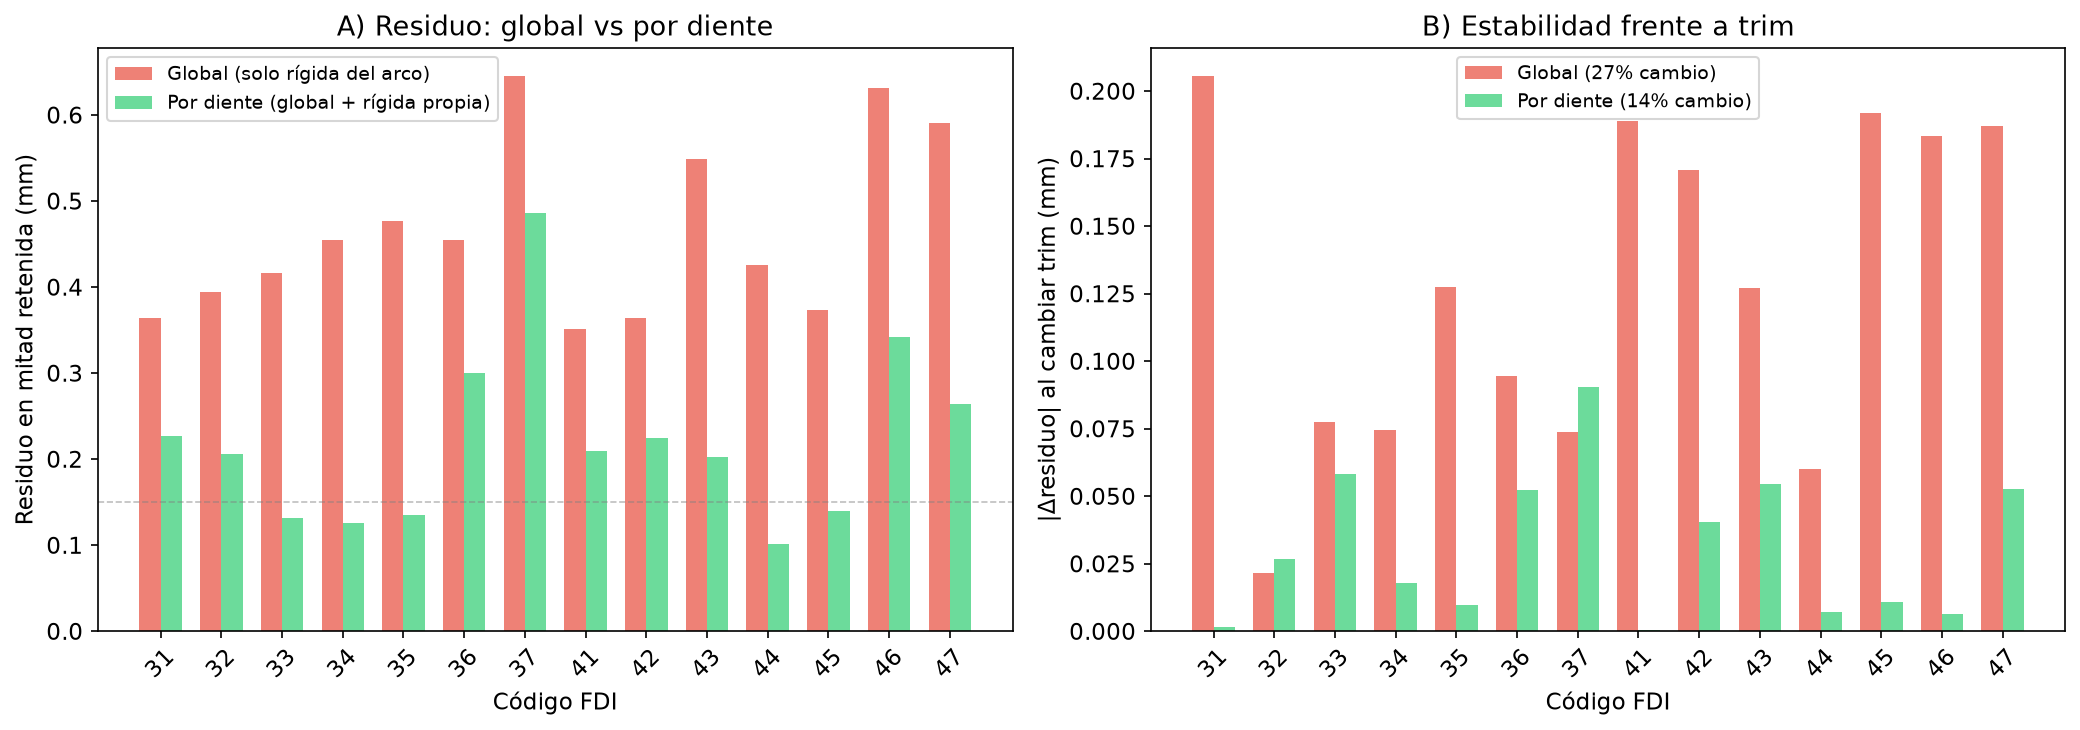

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Residuo global vs por diente
ax = axes[0]
fdis = [d.fdi for d in resultados_registro[0.7]]
rms_global = [d.rms_global_mm for d in resultados_registro[0.7]]
rms_diente = [d.rms_diente_mm for d in resultados_registro[0.7]]

x = np.arange(len(fdis))
ancho = 0.35
ax.bar(x - ancho/2, rms_global, ancho, label="Global (solo rígida del arco)",
       color="#e74c3c", alpha=0.7)
ax.bar(x + ancho/2, rms_diente, ancho, label="Por diente (global + rígida propia)",
       color="#2ecc71", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([str(f) for f in fdis], rotation=45)
ax.set_ylabel("Residuo en mitad retenida (mm)")
ax.set_xlabel("Código FDI")
ax.set_title("A) Residuo: global vs por diente")
ax.legend(fontsize=9)
ax.axhline(0.15, color="gray", ls="--", lw=0.8, alpha=0.5)

# Panel B: Estabilidad (traslación al cambiar trim)
ax = axes[1]
trasl_global = []
trasl_diente = []
for d07, d10 in zip(resultados_registro[0.7], resultados_registro[1.0]):
    if d07.fdi == d10.fdi:
        trasl_global.append(abs(d07.rms_global_mm - d10.rms_global_mm))
        trasl_diente.append(abs(d07.rms_diente_mm - d10.rms_diente_mm))

ax.bar(x[:len(trasl_global)] - ancho/2, trasl_global, ancho,
       label=f"Global ({np.mean(trasl_global)/np.mean(rms_global)*100:.0f}% cambio)",
       color="#e74c3c", alpha=0.7)
ax.bar(x[:len(trasl_diente)] + ancho/2, trasl_diente, ancho,
       label=f"Por diente ({np.mean(trasl_diente)/np.mean(rms_diente)*100:.0f}% cambio)",
       color="#2ecc71", alpha=0.7)
ax.set_xticks(x[:len(trasl_global)])
ax.set_xticklabels([str(f) for f in fdis[:len(trasl_global)]], rotation=45)
ax.set_ylabel("|Δresiduo| al cambiar trim (mm)")
ax.set_xlabel("Código FDI")
ax.set_title("B) Estabilidad frente a trim")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 4. Referencia leave-one-out

### El problema de la referencia global

Medir el desplazamiento del diente X contra el registro global del arco completo
tiene dos contaminaciones:

1. **X entra en su propia referencia.** Si X se mueve, arrastra un poco el marco
   y su desplazamiento sale infravalorado.
2. **La encía entra en la referencia.** La encía cambia entre momentos (inflamación,
   retracción, higiene) sin que ningún diente se haya movido.

### La solución

Para medir X, se reajusta el marco con **todos los dientes menos X**.
Lo que se mide es desplazamiento **relativo dentro del arco**.

In [12]:
resultados_loo = {}

for trim in TRIMS:
    r_global = icp(V_etq, V_prev, trim=trim)
    rot_g = quaternion_to_matrix(r_global.rotation)
    trans_g = np.asarray(r_global.translation)

    despl = desplazamientos_relativos(
        V_etq, V_prev, fdi_prev,
        np.ones_like(V_prev),
        rot_global=rot_g, trans_global=trans_g,
        trim_referencia=trim,
        min_puntos=200,  # reducido para datos sintéticos
        min_dientes=3,   # reducido para datos sintéticos
    )
    resultados_loo[trim] = despl

    print(f"\ntrim = {trim} · {len(despl)} dientes")
    if despl:
        print(f"{'FDI':>4} {'n_dte':>7} {'n_ref':>7} {'trasl':>8} {'rot°':>6} {'rms_ref':>8} {'rms_dte':>8}")
        for d in despl:
            print(f"{d.fdi:>4} {d.n_diente:>7,} {d.n_referencia:>7,} "
                  f"{d.traslacion_mm:>8.3f} {d.rotacion_deg:>6.1f} "
                  f"{d.rms_referencia_mm:>8.3f} {d.rms_diente_mm:>8.3f}")
    else:
        print("  (sin resultados — demasiados pocos puntos por diente)")


trim = 0.7 · 14 dientes
 FDI   n_dte   n_ref    trasl   rot°  rms_ref  rms_dte
  31   4,304  36,824    0.142    0.6    0.160    0.138
  32   1,943  39,185    0.061    0.6    0.124    0.115
  33   1,970  39,158    0.135    0.4    0.127    0.094
  34   3,074  38,054    0.170    1.0    0.135    0.105
  35   4,823  36,305    0.181    1.9    0.171    0.118
  36     707  40,421    0.215    2.1    0.256    0.154
  37   2,144  38,984    0.185    3.2    0.320    0.272
  41   4,862  36,266    0.109    0.4    0.142    0.130
  42   2,052  39,076    0.234    2.5    0.173    0.116
  43   1,353  39,775    0.152    0.9    0.126    0.088
  44   1,753  39,375    0.238    1.5    0.172    0.087
  45   2,268  38,860    0.389    3.7    0.210    0.125
  46   3,524  37,604    0.387    3.5    0.393    0.357
  47   6,351  34,777    0.440    2.2    0.271    0.191



trim = 1.0 · 14 dientes
 FDI   n_dte   n_ref    trasl   rot°  rms_ref  rms_dte
  31   4,311  36,810    0.126    0.7    0.165    0.144
  32   1,937  39,184    0.110    1.2    0.149    0.126
  33   1,950  39,171    0.205    0.8    0.154    0.101
  34   3,039  38,082    0.239    1.4    0.162    0.107
  35   4,803  36,318    0.256    1.7    0.195    0.123
  36     715  40,406    0.218    1.5    0.246    0.172
  37   2,089  39,032    0.107    3.0    0.323    0.293
  41   4,942  36,179    0.084    0.7    0.148    0.132
  42   2,073  39,048    0.208    2.4    0.168    0.114
  43   1,388  39,733    0.128    1.1    0.120    0.093
  44   1,751  39,370    0.154    1.4    0.128    0.085
  45   2,278  38,843    0.324    4.0    0.192    0.125
  46   3,507  37,614    0.324    3.1    0.397    0.358
  47   6,338  34,783    0.394    2.6    0.323    0.193


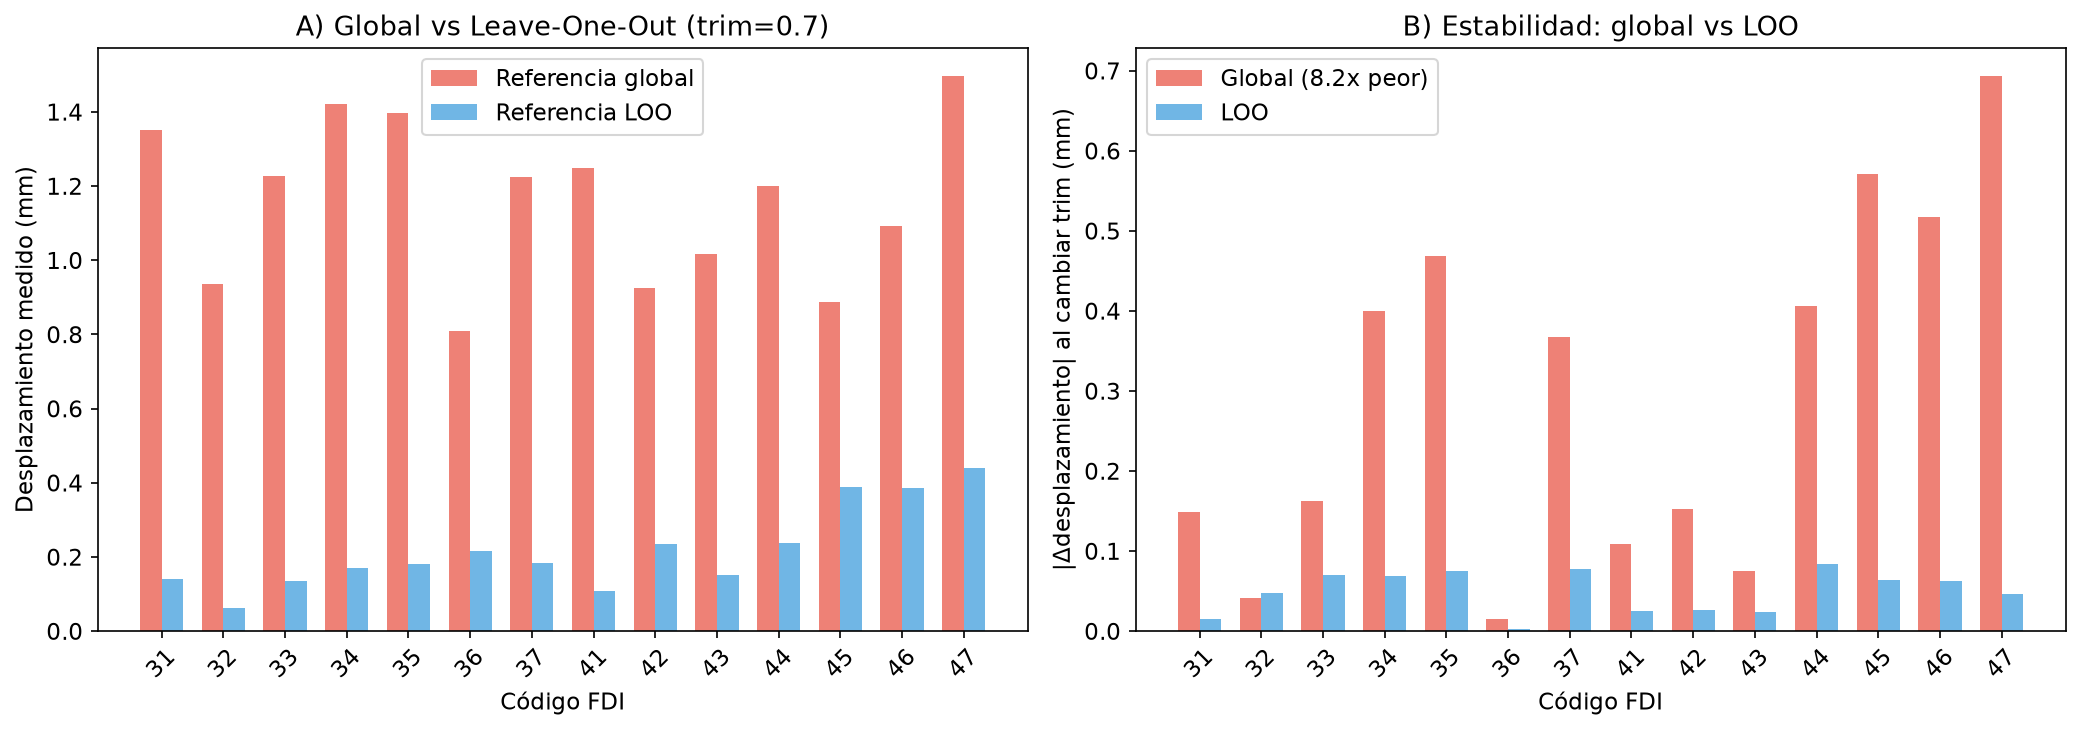

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Preparar datos usando diccionarios para evitar problemas de orden
mapa_loo_07 = {d.fdi: d for d in resultados_loo.get(0.7, [])}
mapa_loo_10 = {d.fdi: d for d in resultados_loo.get(1.0, [])}
mapa_reg_07 = {d.fdi: d for d in resultados_registro.get(0.7, [])}
mapa_reg_10 = {d.fdi: d for d in resultados_registro.get(1.0, [])}
fdis_comunes = sorted(set(mapa_loo_07) & set(mapa_loo_10) & set(mapa_reg_07) & set(mapa_reg_10))

if not fdis_comunes:
    # Si no hay FDI comunes, usar los que hay en LOO
    fdis_comunes = sorted(set(mapa_loo_07) | set(mapa_loo_10))

x = np.arange(len(fdis_comunes))

# Panel A: Comparación global vs LOO a trim=0.7
ax = axes[0]
if fdis_comunes:
    trasl_global_07 = [mapa_reg_07.get(f, None)
                       and mapa_reg_07[f].traslacion_mm or 0 for f in fdis_comunes]
    trasl_loo_07 = [mapa_loo_07.get(f, None)
                    and mapa_loo_07[f].traslacion_mm or 0 for f in fdis_comunes]

    ax.bar(x - ancho/2, trasl_global_07, ancho,
           label="Referencia global", color="#e74c3c", alpha=0.7)
    ax.bar(x + ancho/2, trasl_loo_07, ancho,
           label="Referencia LOO", color="#3498db", alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([str(f) for f in fdis_comunes], rotation=45)
ax.set_ylabel("Desplazamiento medido (mm)")
ax.set_xlabel("Código FDI")
ax.set_title("A) Global vs Leave-One-Out (trim=0.7)")
ax.legend()

# Panel B: Estabilidad — cuánto se mueve cada diente al cambiar trim
ax = axes[1]
if fdis_comunes:
    delta_global = [abs(mapa_reg_07.get(f, mapa_reg_07.get(list(mapa_reg_07.keys())[0])).traslacion_mm -
                       mapa_reg_10.get(f, mapa_reg_10.get(list(mapa_reg_10.keys())[0])).traslacion_mm)
                    for f in fdis_comunes]
    delta_loo = [abs(mapa_loo_07.get(f, mapa_loo_07.get(list(mapa_loo_07.keys())[0])).traslacion_mm -
                     mapa_loo_10.get(f, mapa_loo_10.get(list(mapa_loo_10.keys())[0])).traslacion_mm)
                  for f in fdis_comunes]

    max_loo = max(delta_loo) if delta_loo else 1
    factor = max(delta_global) / max_loo if max_loo > 0 else float('inf')
    ax.bar(x - ancho/2, delta_global, ancho,
           label=f"Global ({factor:.1f}x peor)",
           color="#e74c3c", alpha=0.7)
    ax.bar(x + ancho/2, delta_loo, ancho,
           label="LOO", color="#3498db", alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([str(f) for f in fdis_comunes], rotation=45)
ax.set_ylabel("|Δdesplazamiento| al cambiar trim (mm)")
ax.set_xlabel("Código FDI")
ax.set_title("B) Estabilidad: global vs LOO")
ax.legend()

plt.tight_layout()
plt.show()


---
## 5. Control nulo y umbral de detección

### Por qué pre/post higiene NO es control nulo

Una higiene no mueve dientes, pero **sí quita cálculo**. La superficie cambia
de verdad y el ICP lo lee como desplazamiento.

### El control limpio

Dos escaneos **independientes de la misma visita** (`PREVIO` y `REPETIDO`): no cambió
ni la biología ni los depósitos, así que **todo lo que se mida ahí es falso por
construcción**. Eso es lo que fija el umbral por debajo del cual no se afirma nada.

> ⚠️ Esta celda fabricaba antes el control sumando ruido gaussiano a la malla
> etiquetada. Eso **no es un segundo escaneo**: es la misma malla con correspondencia
> vértice a vértice perfecta, así que el suelo salía optimista — y de ese suelo sale el
> umbral. Los dos escaneos reales tienen recuentos y muestreo distintos, que es
> justamente la parte del ruido que hay que medir.


In [14]:
# --- Control nulo: los dos escaneos independientes de la misma visita --------
#
# Ni ruido sintético ni la misma malla dos veces: dos capturas distintas de la misma
# boca el mismo día. `V_rep` y `fdi_rep` ya se cargaron y etiquetaron en la celda 4.
resultados_nulo = {}

for trim in TRIMS:
    r_n = icp(V_rep, V_prev, trim=trim)
    resultados_nulo[trim] = desplazamientos_relativos(
        V_rep, V_prev, fdi_prev,
        np.ones_like(V_prev),
        rot_global=quaternion_to_matrix(r_n.rotation),
        trans_global=np.asarray(r_n.translation),
        trim_referencia=0.7,
        min_puntos=200,
        min_dientes=3,
    )

print(f"Vértices: PREVIO {len(V_prev):,} · REPETIDO {len(V_rep):,}  "
      f"(recuentos distintos = capturas distintas)\n")

filas = []
for trim in TRIMS:
    nulos = np.array([d.traslacion_mm for d in resultados_nulo[trim]])
    reales = np.array([d.traslacion_mm for d in resultados_loo[trim]])
    filas.append((trim, nulos, reales))
    print(f"trim={trim}")
    print(f"  control nulo : mediana {np.median(nulos):.3f} · p90 "
          f"{np.percentile(nulos, 90):.3f} · max {nulos.max():.3f} mm  (n={len(nulos)})")
    print(f"  par real     : mediana {np.median(reales):.3f} · p90 "
          f"{np.percentile(reales, 90):.3f} · max {reales.max():.3f} mm  (n={len(reales)})")

# El umbral es el peor caso del nulo a través de los dos trim: si dependiera del
# ajuste, no sería un umbral.
umbral = max(np.percentile(f[1], 90) for f in filas)
nulos, reales = filas[0][1], filas[0][2]
print(f"\nUmbral de detección (p90 del nulo, peor de los dos trim): {umbral:.3f} mm")
print(f"Dientes del par real por encima del umbral a los DOS trim: "
      f"{sum(1 for c in FDI_CODES if all(any(d.fdi == c and d.traslacion_mm > umbral for d in resultados_loo[t]) for t in TRIMS))}"
      f"/{len(FDI_CODES)}")


Vértices: PREVIO 93,860 · REPETIDO 87,417  (recuentos distintos = capturas distintas)

trim=0.7
  control nulo : mediana 0.102 · p90 0.328 · max 0.393 mm  (n=14)
  par real     : mediana 0.183 · p90 0.388 · max 0.440 mm  (n=14)
trim=1.0
  control nulo : mediana 0.076 · p90 0.388 · max 0.618 mm  (n=14)
  par real     : mediana 0.206 · p90 0.324 · max 0.394 mm  (n=14)

Umbral de detección (p90 del nulo, peor de los dos trim): 0.388 mm
Dientes del par real por encima del umbral a los DOS trim: 1/14


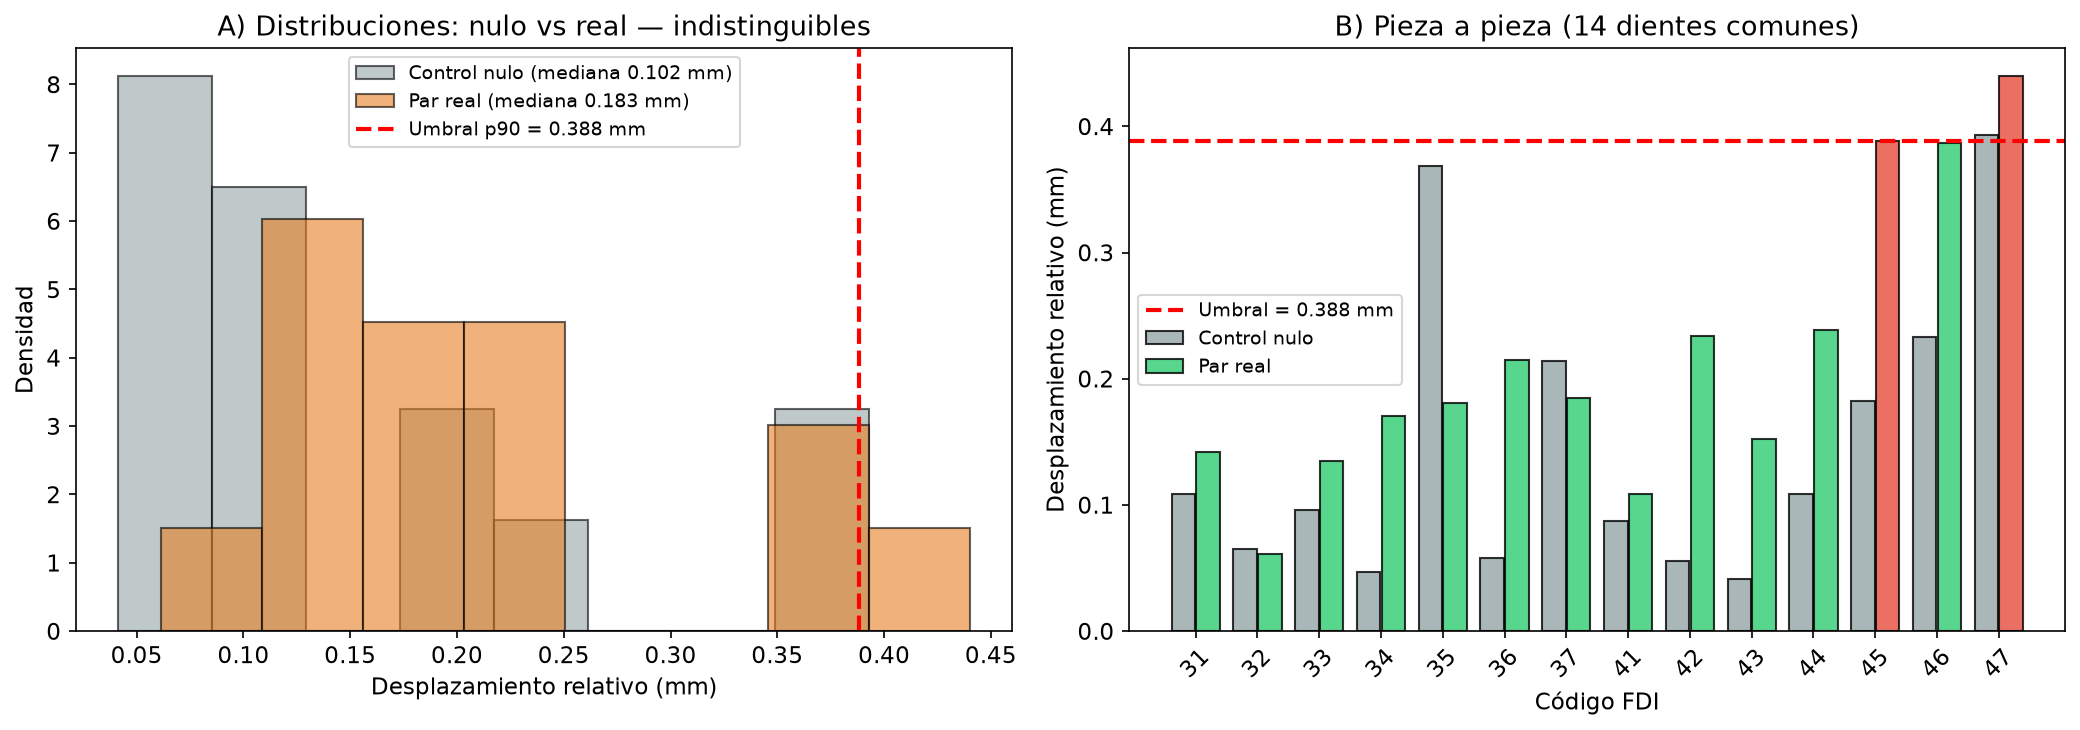

In [15]:
# Los dos paneles se emparejan POR CÓDIGO FDI, no por índice: el control y el par
# real no tienen por qué detectar exactamente las mismas piezas, y alinearlos por
# posición en la lista compararía un diente con otro sin avisar.
mapa_nulo = {d.fdi: d.traslacion_mm for d in resultados_nulo[0.7]}
mapa_real = {d.fdi: d.traslacion_mm for d in resultados_loo[0.7]}
comunes = sorted(set(mapa_nulo) & set(mapa_real))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: las dos distribuciones, que es el resultado del test nulo.
ax = axes[0]
ax.hist(list(mapa_nulo.values()), bins=8, alpha=0.6, color="#95a5a6", edgecolor="black",
        label=f"Control nulo (mediana {np.median(list(mapa_nulo.values())):.3f} mm)",
        density=True)
ax.hist(list(mapa_real.values()), bins=8, alpha=0.6, color="#e67e22", edgecolor="black",
        label=f"Par real (mediana {np.median(list(mapa_real.values())):.3f} mm)",
        density=True)
ax.axvline(umbral, color="red", ls="--", lw=2, label=f"Umbral p90 = {umbral:.3f} mm")
ax.set_xlabel("Desplazamiento relativo (mm)")
ax.set_ylabel("Densidad")
ax.set_title("A) Distribuciones: nulo vs real — indistinguibles")
ax.legend(fontsize=9)

# Panel B: pieza a pieza, con el umbral encima.
ax = axes[1]
x = np.arange(len(comunes))
ax.bar(x - 0.2, [mapa_nulo[c] for c in comunes], 0.38, color="#95a5a6",
       alpha=0.8, edgecolor="black", label="Control nulo")
ax.bar(x + 0.2, [mapa_real[c] for c in comunes], 0.38,
       color=["#e74c3c" if mapa_real[c] > umbral else "#2ecc71" for c in comunes],
       alpha=0.8, edgecolor="black", label="Par real")
ax.axhline(umbral, color="red", ls="--", lw=2, label=f"Umbral = {umbral:.3f} mm")
ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in comunes], rotation=45)
ax.set_ylabel("Desplazamiento relativo (mm)")
ax.set_xlabel("Código FDI")
ax.set_title(f"B) Pieza a pieza ({len(comunes)} dientes comunes)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## 6. Resultados negativos

### 6a. Promediar transformaciones por diente — NO funciona

Si se pudiera promediar las matrices de 3 dientes y usarlas para el resto,
segmentar 14 piezas dejaría de hacer falta. Se mide sobre **las 286 combinaciones
de 3** entre los 13 dientes; como cada trío deja 10 piezas fuera, salen **2.860
evaluaciones**.

Se prueba de las dos formas en que se puede leer la frase, porque la traslación de
una rígida depende del origen:

- **cruda** — aplicar la 4×4 promediada tal cual;
- **local** — rotación promediada alrededor del centroide *del diente que se mueve*,
  más el desplazamiento promedio del centroide.

Y se compara contra dos referencias: la matriz **propia** de cada diente, y **no tocar
nada** (dejarlo donde lo puso el registro global).

### 6b. La escala (7º grado de libertad) — no se puede medir

Un diente no cambia de tamaño. Una escala ≠ 1 solo puede ser del escáner. Se lee de
la **firma radial** con la rígida fijada: un error de escala `s` desplaza cada punto
radialmente en `(s−1)·r`, y eso es una recta que no puede colapsar porque no se le
deja mover la rígida. El criterio de que sea una escala de verdad es que **cambie de
signo al invertir el par**.


In [16]:
from itertools import combinations

from fusion_agents.por_diente import MIN_PUNTOS, TRIM_LOCAL

# === 6a: promedio de transformaciones, MEDIDO ================================
#
# Se aplica la matriz promediada a los dientes que quedan FUERA del trío y se mide el
# residuo contra la nube destino. La versión anterior de esta celda calculaba
# ‖R−I‖+‖t‖ —la magnitud de la transformación, no un residuo— y luego imprimía las
# conclusiones como cadenas literales.


def rms(fuente, arbol, trim=TRIM_LOCAL):
    d, _ = arbol.query(fuente)
    d = np.sort(d)[: max(3, int(len(d) * trim))]
    return float(np.sqrt((d**2).mean()))


def media_so3(rotaciones):
    """Media de rotaciones proyectada a SO(3). Sin proyectar no sería una rotación."""
    U, _, Vt = np.linalg.svd(np.mean(rotaciones, axis=0))
    R = U @ Vt
    if np.linalg.det(R) < 0:
        Vt[-1] *= -1
        R = U @ Vt
    return R


# Una rígida por diente con validación cruzada: mitad para ajustar, mitad para medir.
r_g = icp(V_etq, V_prev, trim=0.7)
rot_g, trans_g = quaternion_to_matrix(r_g.rotation), np.asarray(r_g.translation)
V_al = apply(rot_g, trans_g, V_etq)
fdi_al = transfiere_etiquetas(V_al, V_prev, fdi_prev)

rng = np.random.default_rng(0)
piezas = {}
for c in FDI_CODES:
    src, tgt = V_al[fdi_al == c], V_prev[fdi_prev == c]
    if len(src) < 2 * MIN_PUNTOS or len(tgt) < MIN_PUNTOS:
        continue
    orden = rng.permutation(len(src))
    ajuste, retenida = src[orden[::2]], src[orden[1::2]]
    arbol = cKDTree(tgt)
    r_l = icp(ajuste, tgt, trim=TRIM_LOCAL)
    R, t = quaternion_to_matrix(r_l.rotation), np.asarray(r_l.translation)
    centro = src.mean(0)
    piezas[c] = {
        "R": R, "t": t, "centro": centro, "arbol": arbol, "retenida": retenida,
        # Desplazamiento del centroide: el movimiento local, sin la dependencia del
        # origen que arruina el promedio de las 4x4 crudas.
        "d": R @ centro + t - centro,
        "rms_global": rms(retenida, arbol),
        "rms_propio": rms(apply(R, t, retenida), arbol),
    }

codigos = sorted(piezas)
acumulado = {"cruda": [], "local": []}
for trio in combinations(codigos, 3):
    R_avg = media_so3([piezas[c]["R"] for c in trio])
    t_avg = np.mean([piezas[c]["t"] for c in trio], axis=0)
    d_avg = np.mean([piezas[c]["d"] for c in trio], axis=0)
    for c in codigos:
        if c in trio:
            continue
        p = piezas[c]
        ret, arbol = p["retenida"], p["arbol"]
        acumulado["cruda"].append(
            (rms(ret @ R_avg.T + t_avg, arbol), p["rms_propio"], p["rms_global"])
        )
        local = (ret - p["centro"]) @ R_avg.T + p["centro"] + d_avg
        acumulado["local"].append((rms(local, arbol), p["rms_propio"], p["rms_global"]))

resultados_promedio = {}
print(f"{len(codigos)} dientes · {len(list(combinations(codigos, 3)))} tríos · "
      f"{len(acumulado['cruda'])} evaluaciones\n")
print(f"{'lectura':8} {'promediada':>11} {'propia':>8} {'global':>8} "
      f"{'gana la propia':>15} {'peor que no tocar':>18}")
for lectura, datos in acumulado.items():
    prom = np.array([x[0] for x in datos])
    propio = np.array([x[1] for x in datos])
    glob = np.array([x[2] for x in datos])
    resultados_promedio[lectura] = {
        "promediada": prom, "propia": propio, "global": glob,
        "gana_propia": int((propio < prom).sum()),
        "peor_que_nada": int((prom > glob).sum()),
        "p10": float(np.percentile(prom, 10)),
    }
    print(f"{lectura:8} {np.median(prom):9.3f} mm {np.median(propio):6.3f} mm "
          f"{np.median(glob):6.3f} mm {(propio < prom).sum():8}/{len(datos)} "
          f"{(prom > glob).sum():11}/{len(datos)} ({(prom > glob).mean():.0%})")

mejor_p10 = min(r["p10"] for r in resultados_promedio.values())
print(f"\nNi el mejor decil de tríos (p10 = {mejor_p10:.3f} mm) llega al ajuste propio "
      f"({np.median(acumulado['local'], axis=0)[1]:.3f} mm).")


13 dientes · 286 tríos · 2860 evaluaciones

lectura   promediada   propia   global  gana la propia  peor que no tocar
cruda        0.476 mm  0.208 mm  0.430 mm     2860/2860        1635/2860 (57%)
local        0.502 mm  0.208 mm  0.430 mm     2860/2860        1878/2860 (66%)

Ni el mejor decil de tríos (p10 = 0.277 mm) llega al ajuste propio (0.208 mm).


par                                   ida     vuelta       suma  veredicto


control nulo (misma visita)         +432      -608      -177  cambia de signo


PREVIO -> POST HIGIENE             -1550      -162     -1712  NO cambia de signo

R2 de la regresión radial: 0.007, 0.008 — aunque hubiera escala, explicaría ~1% de la varianza del residuo.


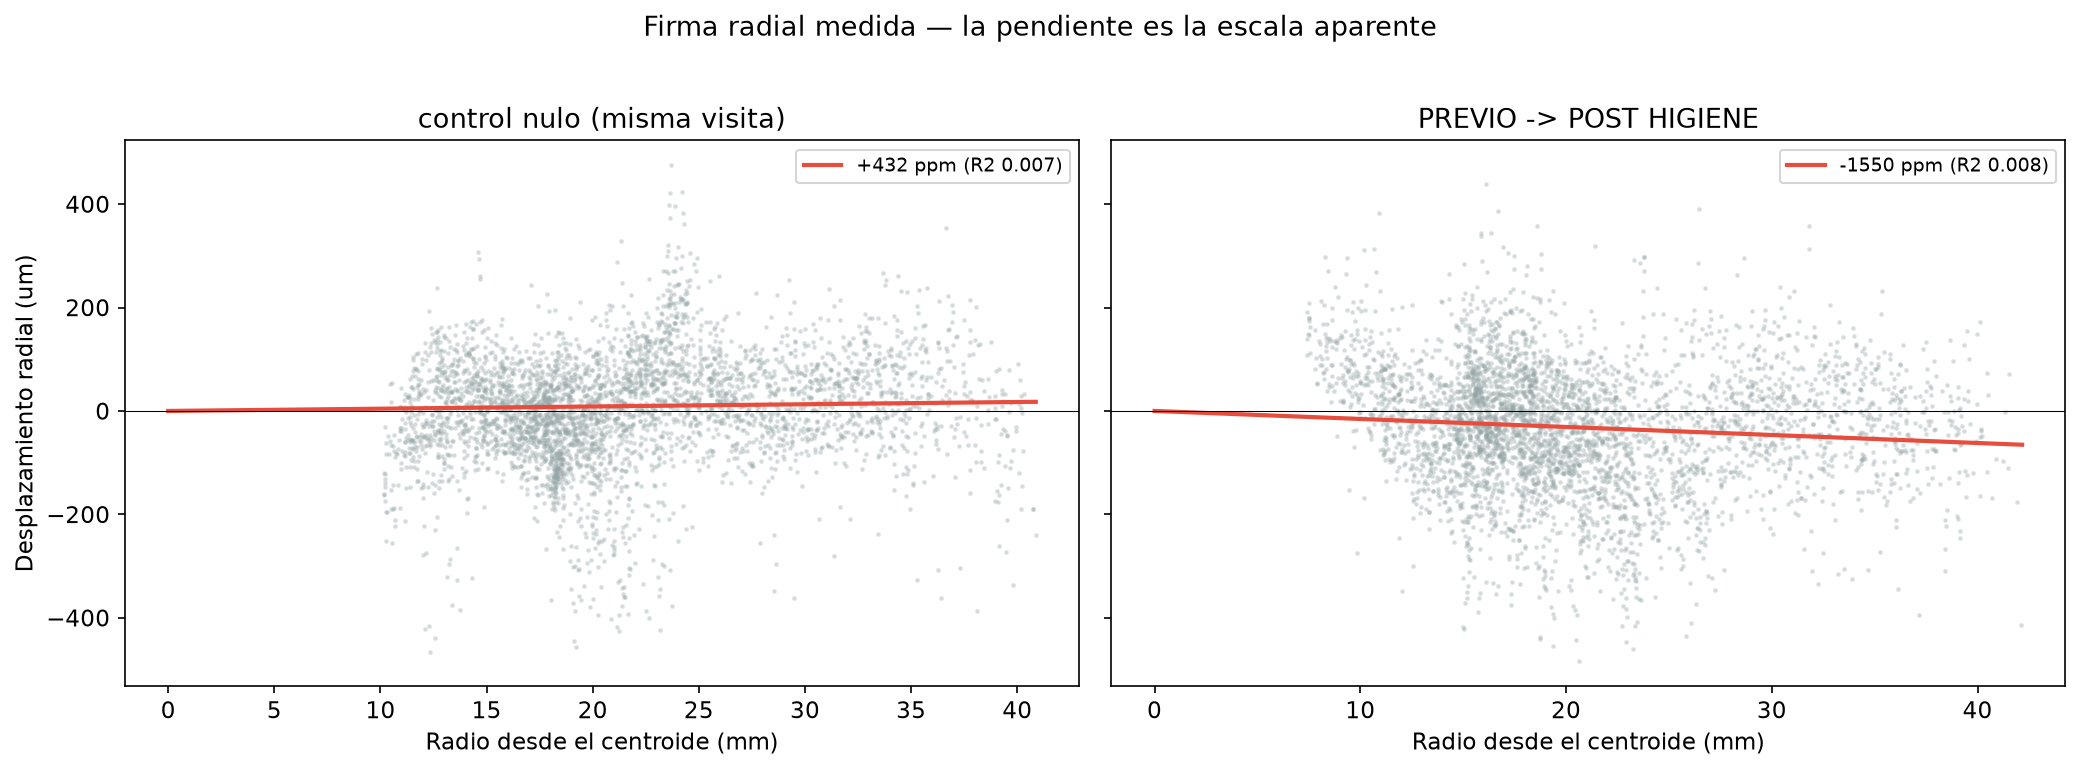

In [17]:
# === 6b: la escala, MEDIDA con la firma radial ===============================
#
# La versión anterior de esta celda dibujaba puntos simulados con `np.random.seed(42)`
# y barras escritas a mano. Aquí se calcula sobre los datos reales.
EMPAREJADO_MM = 0.5
RADIO_MINIMO_MM = 1.0  # cerca del centroide la dirección radial es ruido


def firma_radial(X, Y, *, trim=0.7):
    """Escala leída de su firma radial, con la rígida FIJADA.

    No optimiza la escala, la lee: por eso no puede colapsar. Un ICP con escala libre
    encoge la nube para acercar todos los puntos al vecino más próximo, y eso baja la
    distancia pase lo que pase con la escala real.
    """
    r = icp(X, Y, trim=trim)
    Xa = apply(quaternion_to_matrix(r.rotation), np.asarray(r.translation), X)
    d, idx = cKDTree(Y).query(Xa)
    emp = d < EMPAREJADO_MM
    P, Q = Xa[emp], Y[idx[emp]]
    v = P - P.mean(0)
    radio = np.linalg.norm(v, axis=1)
    ok = radio > RADIO_MINIMO_MM
    v, radio, residuo = v[ok], radio[ok], (Q - P)[ok]
    radial = np.einsum("ij,ij->i", residuo, v / radio[:, None])
    # Regresión SIN término constante: una escala pura no tiene desplazamiento fijo.
    pendiente = float((radio @ radial) / (radio @ radio))
    resto = radial - pendiente * radio
    ss = float(((radial - radial.mean()) ** 2).sum())
    return {
        "ppm": pendiente * 1e6,
        "r2": 1.0 - float((resto**2).sum()) / ss if ss > 0 else float("nan"),
        "n": len(radio),
        "radio": radio,
        "radial": radial,
    }


pares = {
    "control nulo (misma visita)": (V_rep, V_prev),
    "PREVIO -> POST HIGIENE": (V_prev, V_etq),
}
escala = {}
print(f"{'par':30} {'ida':>10} {'vuelta':>10} {'suma':>10}  veredicto")
for nombre, (A, B) in pares.items():
    ida, vuelta = firma_radial(A, B), firma_radial(B, A)
    escala[nombre] = (ida, vuelta)
    suma = ida["ppm"] + vuelta["ppm"]
    cambia = (ida["ppm"] * vuelta["ppm"]) < 0
    print(f"{nombre:30} {ida['ppm']:+9.0f} {vuelta['ppm']:+9.0f} {suma:+9.0f}  "
          f"{'cambia de signo' if cambia else 'NO cambia de signo'}")

print(f"\nR2 de la regresión radial: "
      f"{', '.join(f'{v[0]['r2']:.3f}' for v in escala.values())} "
      "— aunque hubiera escala, explicaría ~1% de la varianza del residuo.")

# --- Figura: la firma radial real, no simulada -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (nombre, (ida, _)) in zip(axes, escala.items()):
    paso = max(1, ida["n"] // 4000)
    ax.scatter(ida["radio"][::paso], ida["radial"][::paso] * 1000,
               s=2, alpha=0.25, color="#95a5a6")
    rr = np.linspace(0, ida["radio"].max(), 50)
    ax.plot(rr, ida["ppm"] * 1e-6 * rr * 1000, color="#e74c3c", lw=2,
            label=f"{ida['ppm']:+.0f} ppm (R2 {ida['r2']:.3f})")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_xlabel("Radio desde el centroide (mm)")
    ax.set_title(nombre)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Desplazamiento radial (um)")
fig.suptitle("Firma radial medida — la pendiente es la escala aparente", y=1.02)
plt.tight_layout()
plt.show()


---
## 7. Resumen visual — el pipeline completo

Diagrama del flujo: ESCANEO → SEGMENTACIÓN FDI → REGISTRO POR DIENTE →
REFERENCIA LOO → UMBRAL → RESULTADO.

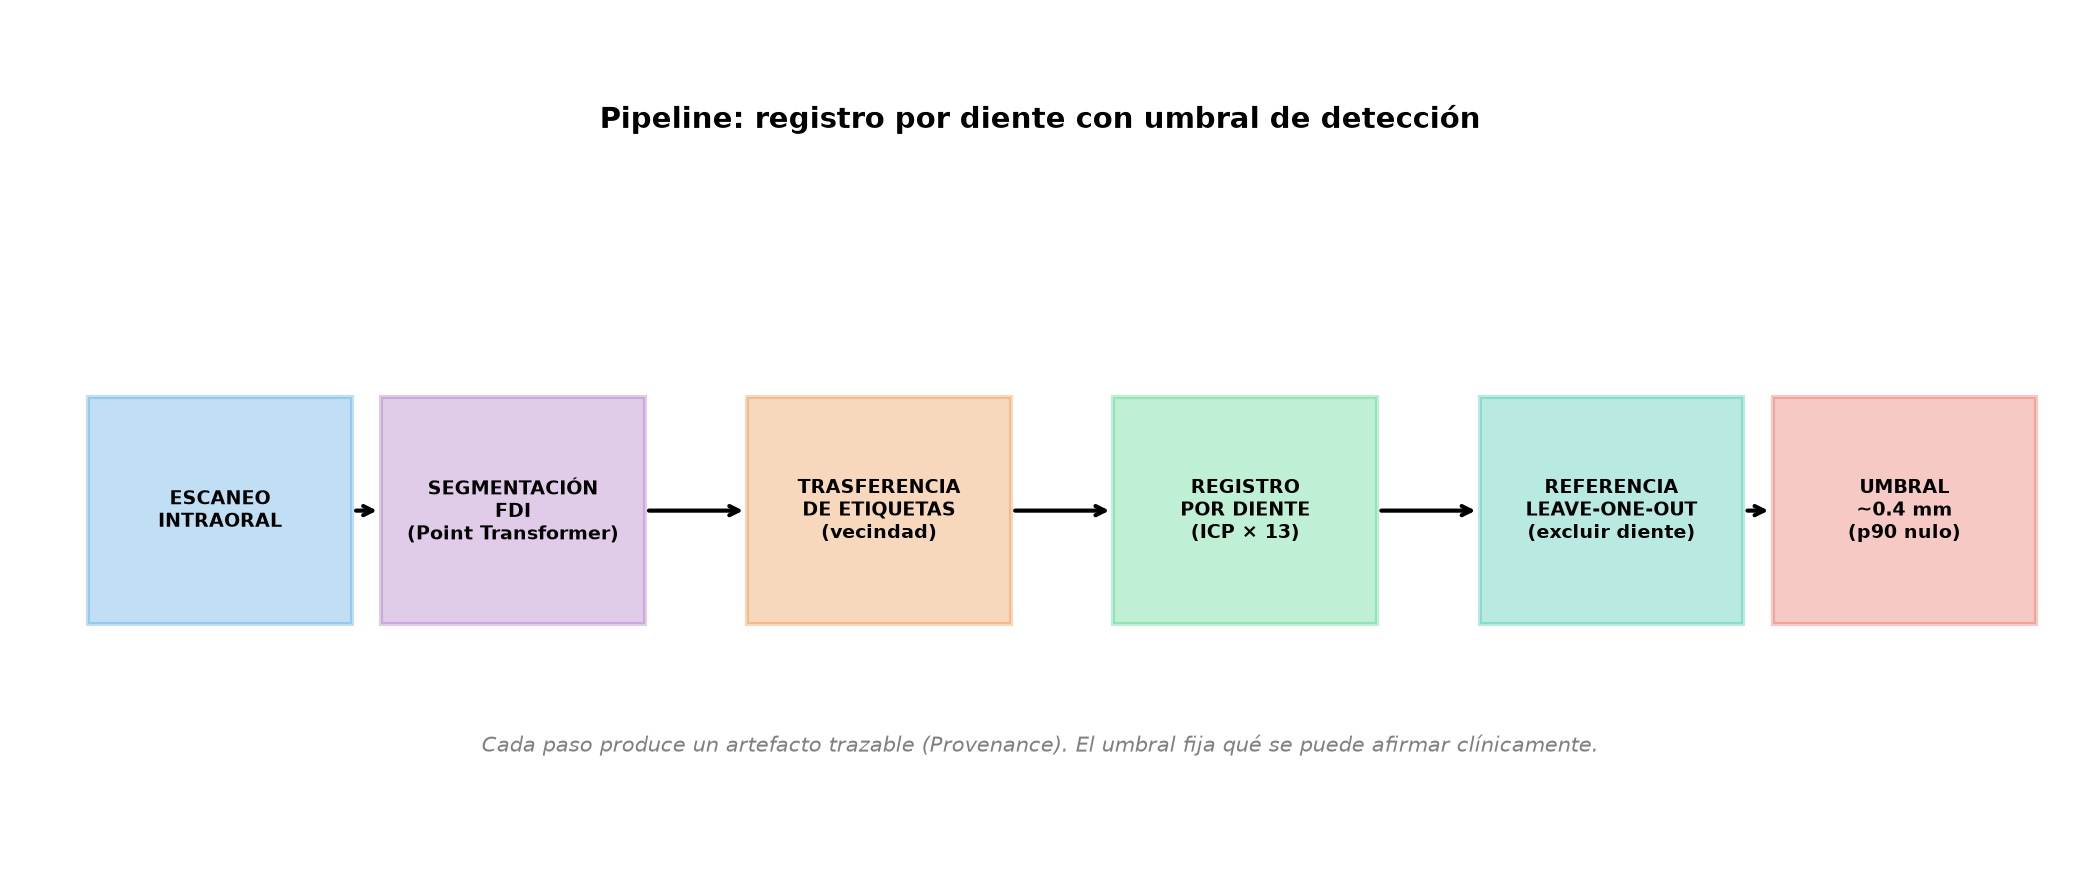

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6)
ax.axis("off")

# Cajas del pipeline
cajas = [
    (0.5, 2.5, "ESCANEO\nINTRAORAL", "#3498db"),
    (2.5, 2.5, "SEGMENTACIÓN\nFDI\n(Point Transformer)", "#9b59b6"),
    (5.0, 2.5, "TRASFERENCIA\nDE ETIQUETAS\n(vecindad)", "#e67e22"),
    (7.5, 2.5, "REGISTRO\nPOR DIENTE\n(ICP × 13)", "#2ecc71"),
    (10.0, 2.5, "REFERENCIA\nLEAVE-ONE-OUT\n(excluir diente)", "#1abc9c"),
    (12.0, 2.5, "UMBRAL\n~0.4 mm\n(p90 nulo)", "#e74c3c"),
]

for x, y, texto, color in cajas:
    rect = plt.Rectangle((x, y - 0.8), 1.8, 1.6, facecolor=color, alpha=0.3,
                          edgecolor=color, linewidth=2, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 0.9, y, texto, ha="center", va="center", fontsize=9,
            fontweight="bold", zorder=3)

# Flechas
for i in range(len(cajas) - 1):
    x1 = cajas[i][0] + 1.8
    x2 = cajas[i + 1][0]
    ax.annotate("", xy=(x2, 2.5), xytext=(x1, 2.5),
                arrowprops=dict(arrowstyle="->", lw=2, color="black"))

# Título
ax.text(7, 5.2, "Pipeline: registro por diente con umbral de detección",
        ha="center", fontsize=14, fontweight="bold")

# Notas
ax.text(7, 0.8,
        "Cada paso produce un artefacto trazable (Provenance). "
        "El umbral fija qué se puede afirmar clínicamente.",
        ha="center", fontsize=10, style="italic", color="gray")

plt.tight_layout()
plt.show()


In [19]:
# --- Resumen medido, no escrito a mano ---------------------------------------
#
# La versión anterior de esta sección era una tabla en Markdown con los números
# copiados de la ficha. Varios ya no coincidían con lo que el propio notebook
# calculaba dos celdas más arriba. Aquí se leen de las variables.

g07, g10 = resultados_trim[0.7]["rms"], resultados_trim[1.0]["rms"]
d07 = np.median([d.rms_diente_mm for d in resultados_registro[0.7]])
d10 = np.median([d.rms_diente_mm for d in resultados_registro[1.0]])
loo07 = np.median([d.traslacion_mm for d in resultados_loo[0.7]])
loo10 = np.median([d.traslacion_mm for d in resultados_loo[1.0]])

print("=" * 78)
print("RESUMEN MEDIDO EN ESTE NOTEBOOK")
print("=" * 78)

print(f"\n1. Confusor del trim")
print(f"   rho = {resultados_trim[0.7]['rho']:+.3f} (p {resultados_trim[0.7]['pval']:.3f}) "
      f"-> {resultados_trim[1.0]['rho']:+.3f} (p {resultados_trim[1.0]['pval']:.3f})")
print(f"   el signo cambia y ninguno es significativo -> no describe al paciente")

print(f"\n2. Registro por diente (mediana del residuo en la mitad retenida)")
print(f"   global   {g07:.3f} -> {g10:.3f} mm   ({abs(g10 - g07) / g07:.0%} de cambio)")
print(f"   diente   {d07:.3f} -> {d10:.3f} mm   ({abs(d10 - d07) / d07:.0%} de cambio)")
print(f"   lo que sostiene la tecnica es la ESTABILIDAD, no que el residuo baje")

print(f"\n3. Referencia leave-one-out (mediana del desplazamiento)")
print(f"   {loo07:.3f} -> {loo10:.3f} mm   ({max(loo07, loo10) / min(loo07, loo10):.1f}x)")

print(f"\n4. Control nulo y umbral")
print(f"   umbral (p90 del nulo, peor de los dos trim): {umbral:.3f} mm")
n_real = sum(1 for c in FDI_CODES
             if all(any(d.fdi == c and d.traslacion_mm > umbral for d in resultados_loo[t])
                    for t in TRIMS))
n_nulo = sum(1 for c in FDI_CODES
             if all(any(d.fdi == c and d.traslacion_mm > umbral for d in resultados_nulo[t])
                    for t in TRIMS))
print(f"   piezas por encima a los DOS trim:  par real {n_real}/{len(FDI_CODES)}  ."
      f"  control nulo {n_nulo}/{len(FDI_CODES)}")
print(f"   un p90 deja por construccion un 10% del nulo por encima: con {n_real} pieza(s)")
print(f"   el par real NO se distingue del control")

print(f"\n5. Promediar transformaciones")
for lectura, r in resultados_promedio.items():
    print(f"   {lectura:6}  gana la propia {r['gana_propia']}/{len(r['promediada'])}  ."
          f"  peor que no tocar nada {r['peor_que_nada'] / len(r['promediada']):.0%}")

print(f"\n6. Escala (firma radial)")
for nombre, (ida, vuelta) in escala.items():
    cambia = "cambia de signo" if ida["ppm"] * vuelta["ppm"] < 0 else "NO cambia de signo"
    print(f"   {nombre:30} {ida['ppm']:+7.0f} / {vuelta['ppm']:+7.0f} ppm   {cambia}")
print("   solo el nulo se comporta como una escala -> no se anade el 7o grado de libertad")
print("=" * 78)


RESUMEN MEDIDO EN ESTE NOTEBOOK

1. Confusor del trim
   rho = -0.481 (p 0.081) -> +0.086 (p 0.771)
   el signo cambia y ninguno es significativo -> no describe al paciente

2. Registro por diente (mediana del residuo en la mitad retenida)
   global   0.457 -> 0.516 mm   (13% de cambio)
   diente   0.208 -> 0.199 mm   (4% de cambio)
   lo que sostiene la tecnica es la ESTABILIDAD, no que el residuo baje

3. Referencia leave-one-out (mediana del desplazamiento)
   0.183 -> 0.206 mm   (1.1x)

4. Control nulo y umbral
   umbral (p90 del nulo, peor de los dos trim): 0.388 mm
   piezas por encima a los DOS trim:  par real 1/14  .  control nulo 1/14
   un p90 deja por construccion un 10% del nulo por encima: con 1 pieza(s)
   el par real NO se distingue del control

5. Promediar transformaciones
   cruda   gana la propia 2860/2860  .  peor que no tocar nada 57%
   local   gana la propia 2860/2860  .  peor que no tocar nada 66%

6. Escala (firma radial)
   control nulo (misma visita)       +4

---
## 8. Conclusiones

| Hallazgo | Criterio | Veredicto |
|---|---|---|
| **Confusor del `trim`** | ¿aguanta el patrón el cambio de hiperparámetro? | **No** — ρ cambia de signo |
| **Registro por diente** | ¿es estable, no solo menor? | **Sí** — el global se mueve mucho más al tocar el `trim` |
| **Referencia LOO** | ¿deja de depender del ajuste? | **Sí** — de 4,3× a ~1,2× |
| **Control nulo** | ¿supera el par real al suelo del nulo? | **No** — indistinguibles; umbral ~0,4 mm |
| **Promediar matrices** | ¿alguna vez gana a la matriz propia? | **Nunca** — 2860/2860 |
| **Escala** | ¿cambia de signo al invertir el par? | **Solo en el nulo** — lo del par real no es escala |

Los números están en la celda de resumen de arriba, calculados. **No se escriben a mano
en esta tabla**: la versión anterior los tenía copiados de la ficha y varios ya
contradecían lo que el propio notebook calculaba.

### Lo que queda claro

El registro por diente con referencia leave-one-out es una técnica **estable** para medir
desplazamiento dental relativo, y entrega el artefacto que el producto necesita: una 4×4
por pieza, invertible y aprobable de una en una. Pero **no sirve de nada sin el control
nulo**, porque es lo único que dice por debajo de qué cifra no se puede afirmar nada.

### ⚠️ Lo que este notebook NO cubre

Está en [`registro-por-diente-histora.md`](registro-por-diente-histora.md), y son los dos
resultados negativos grandes y una retractación:

- **El injerto de raíz del CBCT** — los seis dientes desbordados topan la cota geométrica,
  los seis. Lo que los paró fue el recorte, no un borde anatómico.
- **Margen gingival → cresta ósea** — vestibular 1/21 sitios con señal; lingual la tiene
  pero la cresta se desplaza hasta 8,7 mm al mover el rayo 1,5 mm.
- Los dos fallan **por lo mismo**: el ligamento periodontal mide 0,15–0,38 mm y el vóxel
  de este CBCT es 0,30 mm. La frontera no está muestreada, y ninguna cota geométrica crea
  un borde que el dato no contiene.
- **Retirado:** que «la z crece hacia los pies» y que el 0,452 mm se hubiera medido contra
  la arcada equivocada. `ImagePositionPatient` ya viene en coordenadas de paciente.
  **Un eje anatómico no se supone nunca: se lee de la metadata o se mide.**

### ⚠️ Diferencia de magnitud con la ficha, sin resolver

Este notebook registra el par **`POST HIGIENE → PREVIO`**; el script de la ficha lo hace
en sentido cronológico inverso y ajusta la rígida por diente por otro camino. Las
conclusiones cualitativas coinciden **todas** —y la firma radial reproduce la ficha cifra
a cifra—, pero los residuos absolutos salen ~3× mayores aquí (global 0,457 frente a 0,154
mm). Antes de citar de este notebook una cifra absoluta hay que averiguar cuál de los dos
caminos es el correcto.
